# DAACT-YOLO26 — FINAL v4 Research Training Notebook
## Negative-Aware Density- and Assessability-Aware Curriculum Training
### Tree-Trunk Instance Segmentation — Kaggle T4×2 + RAGLO-Bark Ready

This notebook is the corrected Part-1 training/evaluation notebook for the
**frozen audited dataset**:

```text
Train       641 images
Validation  137 images
Test        137 images
Total       915 images

Positive tree-trunk polygons: 4,445

Intentional negative/background images:
Train        32
Validation   11
Test         12
Total        55
```

The 55 empty YOLO label files are **intentional negative samples** and are not
treated as annotation errors.

---

## Technical contribution evaluated

**DAACT-YOLO26** keeps a normal deployable `YOLO26s-seg` architecture and
changes the training procedure:

1. **S0 Common:** learn general trunk representations using all positive
   annotations plus the verified negative/background images.
2. **B0 Standard:** ordinary Stage-2 continuation from the common checkpoint.
3. **A1 Density:** same continuation, but HIGH-density positive scenes receive
   increased exposure.
4. **A2 DAACT (proposed):** A1 density emphasis plus an assessability-aligned
   Stage-2 target set.

All B0/A1/A2 branches use the same:

- S0 checkpoint;
- YOLO26s-seg architecture;
- Stage-2 epoch budget;
- Stage-2 augmentation schedule;
- validation split;
- untouched test split.

---

## Scene groups

The notebook keeps negative images separate from positive-scene density:

```text
NEGATIVE = 0 annotated trunks
LOW      = 1–5 annotated trunks
MEDIUM   = 6–10 annotated trunks
HIGH     = 11+ annotated trunks
```

Expected audited distribution:

```text
TRAIN
negative 32
low      423
medium   120
high      66

VALID
negative 11
low       86
medium    26
high      14

TEST
negative 12
low       85
medium    23
high      17
```

Negative images are never density-oversampled.

---

## RAGLO-Bark output contract

The final proposed A2 detector exports one selected bark ROI and prepares:

```text
selected_bark_roi.png
global_384.png
patch_1_224.png
patch_2_224.png
patch_3_224.png
patch_4_224.png
```

RAGLO preparation remains:

- global image: `384 × 384`;
- four local images: `224 × 224`;
- deterministic `2 × 2` layout;
- patch fraction: `0.58`;
- aspect-fit resize + ImageNet-neutral padding;
- ImageNet normalization metadata.

The notebook does not claim benefit unless the B0/A1/A2 ablation supports it.

## Kaggle setup

### Recommended dataset source

Upload the **audited local dataset_split** directly as a private Kaggle Dataset,
then use **Add Input** in this notebook.

The Kaggle input may contain either:

```text
dataset_split/
├── train/images
├── train/labels
├── valid/images
├── valid/labels
├── test/images
├── test/labels
└── data.yaml
```

or a `.zip` containing that structure.

This notebook automatically:

1. searches `/kaggle/input`;
2. extracts dataset ZIP files when required;
3. locates the YOLO dataset root;
4. verifies the exact frozen split;
5. verifies all 4,445 positive polygons;
6. verifies the 55 intentional negatives;
7. copies the frozen dataset to `/kaggle/working`;
8. only then starts DAACT training.

### Kaggle settings

- Accelerator: **GPU T4 × 2**
- Internet: **ON** for first-time model package/weight download
- No Roboflow secret is required for the recommended workflow.

## 1 — Install dependencies

In [3]:
!pip -q install \
  "ultralytics>=8.4.115,<8.5" \
  "opencv-python-headless>=4.10" \
  "pyyaml>=6" \
  "pandas>=2" \
  "numpy>=1.26" \
  "Pillow>=10" \
  "tqdm>=4.66"

## 2 — Environment and T4 compatibility check

In [4]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import gc
import json
import math
import random
import shutil
import hashlib
import subprocess
import sys
import time
from dataclasses import dataclass, asdict
from pathlib import Path
from typing import Any, Optional

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import yaml

from PIL import Image
from tqdm.auto import tqdm

import ultralytics
from ultralytics import YOLO

print("Python:", sys.version)
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA runtime:", torch.version.cuda)
print("Ultralytics:", ultralytics.__version__)

if not torch.cuda.is_available():
    raise RuntimeError(
        "Enable Kaggle GPU: Settings → Accelerator → GPU T4 × 2."
    )

print("GPU count:", torch.cuda.device_count())
for index in range(torch.cuda.device_count()):
    print(index, torch.cuda.get_device_name(index))

cuda_arches = set(torch.cuda.get_arch_list())
print("CUDA architectures in torch:", sorted(cuda_arches))

if "sm_75" not in cuda_arches:
    raise RuntimeError(
        "This PyTorch build does not include T4 (sm_75) support. "
        "Use a Kaggle GPU image with T4-compatible PyTorch before training."
    )

print(
    "Training uses deterministic=False to avoid optional torch._inductor "
    "compatibility failures in some Kaggle images."
)

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
PyTorch: 2.10.0+cu128
CUDA available: True
CUDA runtime: 12.8
Ultralytics: 8.4.115
GPU count: 2
0 Tesla T4
1 Tesla T4
CUDA architectures in torch: ['sm_100', 'sm_120', 'sm_70', 'sm_75', 'sm_80', 'sm_86', 'sm_90']
Training uses deterministic=False to avoid optional torch._inductor compatibility failures in some Kaggle images.


## 3 — Configuration

In [5]:
SEED = 42

@dataclass(frozen=True)
class Config:
    # ---------------- Frozen Kaggle dataset ----------------
    # Leave blank for automatic discovery below /kaggle/input.
    manual_dataset_root: str = ""

    expected_train_images: int = 641
    expected_valid_images: int = 137
    expected_test_images: int = 137
    expected_total_instances: int = 4445

    # Verified intentional negative/background images.
    expected_negative_train: int = 32
    expected_negative_valid: int = 11
    expected_negative_test: int = 12
    strict_negative_counts: bool = True
    strict_expected_instances: bool = True

    class_name: str = "tree_trunk"
    model_name: str = "yolo26s-seg.pt"

    # ---------------- Training ----------------
    imgsz: int = 1024
    global_batch: int = 8
    workers: int = 4

    # Common stage + equal branch budget.
    base_epochs: int = 120
    branch_epochs: int = 40
    patience: int = 30
    seed: int = SEED

    # Assessability operational definition after 1024 letterbox.
    min_assessable_width: float = 40.0
    min_assessable_height: float = 150.0
    min_assessable_area: float = 5000.0

    # Positive-scene density thresholds.
    density_low_max: int = 5
    density_medium_max: int = 10

    # Stage-2 exposure multipliers.
    # Negative images stay at ordinary exposure.
    density_repeat_negative: int = 1
    density_repeat_low: int = 1
    density_repeat_medium: int = 1
    density_repeat_high: int = 2

    # Confidence is selected using VALIDATION only.
    confidence_candidates: tuple = (
        0.20, 0.25, 0.30, 0.35, 0.40, 0.45,
        0.50, 0.55, 0.60, 0.65, 0.70
    )
    match_iou: float = 0.50
    max_det: int = 300

    # Bark-quality gate.
    minimum_mask_occupancy: float = 0.40
    minimum_sharpness: float = 30.0
    minimum_contrast: float = 15.0
    minimum_brightness: float = 25.0
    maximum_brightness: float = 230.0
    bark_candidate_count: int = 5

    # RAGLO deterministic inference contract.
    raglo_global_size: int = 384
    raglo_local_size: int = 224
    raglo_patch_count: int = 4
    raglo_patch_fraction: float = 0.58
    imagenet_mean: tuple = (0.485, 0.456, 0.406)
    imagenet_std: tuple = (0.229, 0.224, 0.225)

    # Ablations.
    run_b0_standard: bool = True
    run_a1_density: bool = True
    run_a2_daact: bool = True

    # Optional RAGLO deployment artifact added as a Kaggle input.
    raglo_artifact_path: str = ""

CFG = Config()

random.seed(CFG.seed)
np.random.seed(CFG.seed)
torch.manual_seed(CFG.seed)
torch.cuda.manual_seed_all(CFG.seed)

WORK = Path("/kaggle/working")
INPUT_ROOT = Path("/kaggle/input")
EXTRACT_ROOT = WORK / "_tree_dataset_extract"
DATASET_DIR = WORK / "tree_trunk_daact_dataset"
CURRICULUM_DIR = WORK / "curriculum_datasets"
RUNS_DIR = WORK / "daact_runs"
OUT_DIR = WORK / "DAACT_YOLO26_Research_Deliverables"
RAGLO_READY_DIR = OUT_DIR / "raglo_ready"
PLOTS_DIR = OUT_DIR / "plots"

for directory in (
    EXTRACT_ROOT,
    CURRICULUM_DIR,
    RUNS_DIR,
    OUT_DIR,
    RAGLO_READY_DIR,
    PLOTS_DIR,
):
    directory.mkdir(parents=True, exist_ok=True)

EXPECTED_NEGATIVES = {
    "train": CFG.expected_negative_train,
    "valid": CFG.expected_negative_valid,
    "test": CFG.expected_negative_test,
}

print(json.dumps(asdict(CFG), indent=2))

{
  "manual_dataset_root": "",
  "expected_train_images": 641,
  "expected_valid_images": 137,
  "expected_test_images": 137,
  "expected_total_instances": 4445,
  "expected_negative_train": 32,
  "expected_negative_valid": 11,
  "expected_negative_test": 12,
  "strict_negative_counts": true,
  "strict_expected_instances": true,
  "class_name": "tree_trunk",
  "model_name": "yolo26s-seg.pt",
  "imgsz": 1024,
  "global_batch": 8,
  "workers": 4,
  "base_epochs": 120,
  "branch_epochs": 40,
  "patience": 30,
  "seed": 42,
  "min_assessable_width": 40.0,
  "min_assessable_height": 150.0,
  "min_assessable_area": 5000.0,
  "density_low_max": 5,
  "density_medium_max": 10,
  "density_repeat_negative": 1,
  "density_repeat_low": 1,
  "density_repeat_medium": 1,
  "density_repeat_high": 2,
  "confidence_candidates": [
    0.2,
    0.25,
    0.3,
    0.35,
    0.4,
    0.45,
    0.5,
    0.55,
    0.6,
    0.65,
    0.7
  ],
  "match_iou": 0.5,
  "max_det": 300,
  "minimum_mask_occupancy": 0.4

## 4 — Resolve and validate the frozen dataset BEFORE training

In [6]:
import zipfile

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}

def list_images(directory: Path) -> list[Path]:
    if not directory.is_dir():
        return []
    return sorted(
        path
        for path in directory.iterdir()
        if path.is_file()
        and path.suffix.lower() in IMAGE_EXTENSIONS
    )

def read_nonempty_lines(path: Path) -> list[str]:
    if not path.is_file():
        return []
    return [
        line.strip()
        for line in path.read_text(
            encoding="utf-8",
            errors="replace",
        ).splitlines()
        if line.strip()
    ]

def validate_segmentation_line(line: str) -> bool:
    parts = line.split()

    if len(parts) < 7:
        return False

    try:
        class_id = int(float(parts[0]))
        coords = np.asarray(
            [float(value) for value in parts[1:]],
            dtype=np.float64,
        )
    except Exception:
        return False

    return bool(
        class_id == 0
        and len(coords) >= 6
        and len(coords) % 2 == 0
        and np.isfinite(coords).all()
        and np.all(coords >= 0.0)
        and np.all(coords <= 1.0)
    )

def split_folder(root: Path, split: str) -> Path | None:
    aliases = {
        "train": ("train",),
        "valid": ("valid", "val", "validation"),
        "test": ("test",),
    }[split]

    for alias in aliases:
        candidate = root / alias
        if (
            (candidate / "images").is_dir()
            and (candidate / "labels").is_dir()
        ):
            return candidate

    return None

def audit_dataset_root(root: Path) -> dict[str, Any] | None:
    root = Path(root)

    split_dirs = {
        split_name: split_folder(root, split_name)
        for split_name in ("train", "valid", "test")
    }

    if any(value is None for value in split_dirs.values()):
        return None

    rows = []
    total_instances = 0
    total_malformed = 0
    total_missing = 0
    total_orphan = 0
    total_negative = 0

    for split_name in ("train", "valid", "test"):
        split_dir = split_dirs[split_name]
        image_dir = split_dir / "images"
        label_dir = split_dir / "labels"

        images = list_images(image_dir)
        label_files = sorted(label_dir.glob("*.txt"))

        image_stems = {path.stem for path in images}
        label_stems = {path.stem for path in label_files}

        missing_labels = sorted(image_stems - label_stems)
        orphan_labels = sorted(label_stems - image_stems)

        instances = 0
        malformed = 0
        negative_images = 0
        nonempty_labels = 0

        for image_path in images:
            label_path = label_dir / f"{image_path.stem}.txt"
            lines = read_nonempty_lines(label_path)

            if label_path.is_file() and not lines:
                # Intentional YOLO background/negative sample.
                negative_images += 1
            elif lines:
                nonempty_labels += 1

            for line in lines:
                if validate_segmentation_line(line):
                    instances += 1
                else:
                    malformed += 1

        rows.append({
            "split": split_name,
            "images": len(images),
            "label_files": len(label_files),
            "nonempty_labels": nonempty_labels,
            "negative_images": negative_images,
            "instances": instances,
            "missing_labels": len(missing_labels),
            "orphan_labels": len(orphan_labels),
            "malformed_lines": malformed,
        })

        total_instances += instances
        total_malformed += malformed
        total_missing += len(missing_labels)
        total_orphan += len(orphan_labels)
        total_negative += negative_images

    frame = pd.DataFrame(rows)

    expected_images = {
        "train": CFG.expected_train_images,
        "valid": CFG.expected_valid_images,
        "test": CFG.expected_test_images,
    }

    image_counts_match = all(
        int(
            frame.loc[
                frame["split"] == split_name,
                "images",
            ].iloc[0]
        ) == expected_count
        for split_name, expected_count in expected_images.items()
    )

    label_counts_match = all(
        int(
            frame.loc[
                frame["split"] == split_name,
                "label_files",
            ].iloc[0]
        ) == expected_images[split_name]
        for split_name in expected_images
    )

    instances_match = (
        total_instances == CFG.expected_total_instances
    )

    negative_counts = {
        row["split"]: int(row["negative_images"])
        for row in frame.to_dict("records")
    }

    negative_counts_match = all(
        negative_counts[split_name]
        == EXPECTED_NEGATIVES[split_name]
        for split_name in EXPECTED_NEGATIVES
    )

    valid = bool(
        image_counts_match
        and label_counts_match
        and total_missing == 0
        and total_orphan == 0
        and total_malformed == 0
        and (
            instances_match
            if CFG.strict_expected_instances
            else total_instances > 0
        )
        and (
            negative_counts_match
            if CFG.strict_negative_counts
            else True
        )
    )

    return {
        "root": root,
        "frame": frame,
        "total_instances": int(total_instances),
        "total_negative_images": int(total_negative),
        "negative_counts": negative_counts,
        "image_counts_match": bool(image_counts_match),
        "label_counts_match": bool(label_counts_match),
        "instances_match": bool(instances_match),
        "negative_counts_match": bool(negative_counts_match),
        "valid": valid,
    }

def candidate_roots_below(base: Path) -> list[Path]:
    roots = set()

    if not base.exists():
        return []

    for yaml_path in base.rglob("data.yaml"):
        roots.add(yaml_path.parent)

    for train_images in base.rglob("train/images"):
        roots.add(train_images.parent.parent)

    return sorted(roots)

def extract_kaggle_zip_inputs() -> list[Path]:
    extracted_roots = []

    shutil.rmtree(EXTRACT_ROOT, ignore_errors=True)
    EXTRACT_ROOT.mkdir(parents=True, exist_ok=True)

    zip_files = sorted(INPUT_ROOT.rglob("*.zip"))

    for index, zip_path in enumerate(zip_files, start=1):
        destination = EXTRACT_ROOT / f"{index:02d}_{zip_path.stem}"
        destination.mkdir(parents=True, exist_ok=True)

        try:
            print("Extracting Kaggle ZIP:", zip_path)
            with zipfile.ZipFile(zip_path, "r") as archive:
                archive.extractall(destination)
            extracted_roots.append(destination)
        except zipfile.BadZipFile:
            print("Skipping invalid ZIP:", zip_path)

    return extracted_roots

def print_audit(name: str, audit: dict[str, Any] | None):
    print("\n" + "=" * 78)
    print(name)

    if audit is None:
        print("Not a complete train/valid/test YOLO segmentation dataset.")
        return

    print("Root:", audit["root"])
    display(audit["frame"])

    print("Positive polygon instances:", audit["total_instances"])
    print("Expected positive instances:", CFG.expected_total_instances)
    print("Intentional negative images:", audit["total_negative_images"])
    print("Expected negatives:", EXPECTED_NEGATIVES)
    print("Image counts match:", audit["image_counts_match"])
    print("Label counts match:", audit["label_counts_match"])
    print("Instance count matches:", audit["instances_match"])
    print("Negative counts match:", audit["negative_counts_match"])
    print("VALID:", audit["valid"])

def resolve_kaggle_dataset() -> dict[str, Any]:
    search_bases = [INPUT_ROOT]

    if CFG.manual_dataset_root:
        manual_root = Path(CFG.manual_dataset_root)
        audit = audit_dataset_root(manual_root)
        print_audit("Manual dataset root", audit)

        if audit is None or not audit["valid"]:
            raise RuntimeError(
                "manual_dataset_root does not match the frozen audited dataset."
            )

        return audit

    # Also support a Kaggle Dataset uploaded as ZIP.
    search_bases.extend(extract_kaggle_zip_inputs())

    candidates = []

    for base in search_bases:
        for root in candidate_roots_below(base):
            audit = audit_dataset_root(root)
            if audit is not None:
                candidates.append(audit)

    if not candidates:
        raise RuntimeError(
            "No train/valid/test YOLO segmentation dataset was found under "
            "/kaggle/input or inside its ZIP files."
        )

    candidates.sort(
        key=lambda item: (
            item["valid"],
            item["image_counts_match"],
            item["instances_match"],
            item["negative_counts_match"],
            item["total_instances"],
        ),
        reverse=True,
    )

    for index, audit in enumerate(candidates[:10], start=1):
        print_audit(f"Kaggle candidate #{index}", audit)

    valid_candidates = [
        audit
        for audit in candidates
        if audit["valid"]
    ]

    if not valid_candidates:
        raise RuntimeError(
            "\nThe Kaggle input does not match the frozen audited dataset.\n\n"
            "Required:\n"
            "641 train / 137 valid / 137 test images\n"
            "4,445 valid tree_trunk polygon instances\n"
            "32 / 11 / 12 intentional negative images\n"
            "0 missing labels\n"
            "0 orphan labels\n"
            "0 malformed polygon lines\n"
        )

    return valid_candidates[0]

def copy_normalized_dataset(source_root: Path) -> None:
    shutil.rmtree(DATASET_DIR, ignore_errors=True)
    DATASET_DIR.mkdir(parents=True, exist_ok=True)

    for split_name in ("train", "valid", "test"):
        source_split = split_folder(source_root, split_name)

        if source_split is None:
            raise FileNotFoundError(
                f"Cannot resolve {split_name} below {source_root}"
            )

        target_split = DATASET_DIR / split_name

        shutil.copytree(
            source_split / "images",
            target_split / "images",
        )
        shutil.copytree(
            source_split / "labels",
            target_split / "labels",
        )

    data_config = {
        "path": str(DATASET_DIR),
        "train": "train/images",
        "val": "valid/images",
        "test": "test/images",
        "nc": 1,
        "names": {0: CFG.class_name},
    }

    with (DATASET_DIR / "data.yaml").open(
        "w",
        encoding="utf-8",
    ) as handle:
        yaml.safe_dump(
            data_config,
            handle,
            sort_keys=False,
        )

selected_audit = resolve_kaggle_dataset()

print("\nSELECTED FROZEN DATASET:", selected_audit["root"])

copy_normalized_dataset(selected_audit["root"])

source_used = "kaggle"
VALID_FOLDER = "valid"
DATA_YAML = DATASET_DIR / "data.yaml"

FINAL_SOURCE_AUDIT = audit_dataset_root(DATASET_DIR)
print_audit("Normalized working dataset", FINAL_SOURCE_AUDIT)

if (
    FINAL_SOURCE_AUDIT is None
    or not FINAL_SOURCE_AUDIT["valid"]
):
    raise RuntimeError(
        "The normalized working copy failed the frozen dataset gate."
    )

FINAL_SOURCE_AUDIT["frame"].to_csv(
    OUT_DIR / "dataset_source_audit.csv",
    index=False,
)

print("\nDATASET SOURCE GATE PASSED.")
print(DATA_YAML.read_text())


Kaggle candidate #1
Root: /kaggle/input/datasets/aselamaduwantha/tree-detection-dataset/dataset_split


,split,images,label_files,nonempty_labels,negative_images,instances,missing_labels,orphan_labels,malformed_lines
0,train,641,641,609,32,3111,0,0,0
1,valid,137,137,126,11,667,0,0,0
2,test,137,137,125,12,667,0,0,0


Positive polygon instances: 4445
Expected positive instances: 4445
Intentional negative images: 55
Expected negatives: {'train': 32, 'valid': 11, 'test': 12}
Image counts match: True
Label counts match: True
Instance count matches: True
Negative counts match: True
VALID: True

SELECTED FROZEN DATASET: /kaggle/input/datasets/aselamaduwantha/tree-detection-dataset/dataset_split

Normalized working dataset
Root: /kaggle/working/tree_trunk_daact_dataset


,split,images,label_files,nonempty_labels,negative_images,instances,missing_labels,orphan_labels,malformed_lines
0,train,641,641,609,32,3111,0,0,0
1,valid,137,137,126,11,667,0,0,0
2,test,137,137,125,12,667,0,0,0


Positive polygon instances: 4445
Expected positive instances: 4445
Intentional negative images: 55
Expected negatives: {'train': 32, 'valid': 11, 'test': 12}
Image counts match: True
Label counts match: True
Instance count matches: True
Negative counts match: True
VALID: True

DATASET SOURCE GATE PASSED.
path: /kaggle/working/tree_trunk_daact_dataset
train: train/images
val: valid/images
test: test/images
nc: 1
names:
  0: tree_trunk



## 5 — Density audit on the validated frozen dataset

In [7]:
def image_files(directory: Path) -> list[Path]:
    return list_images(directory)

def read_label_lines(label_path: Path) -> list[str]:
    return read_nonempty_lines(label_path)

DENSITY_LOW_MAX = int(CFG.density_low_max)
DENSITY_MEDIUM_MAX = int(CFG.density_medium_max)

def density_group_from_count(count: int) -> str:
    if count == 0:
        return "negative"
    if count <= DENSITY_LOW_MAX:
        return "low"
    if count <= DENSITY_MEDIUM_MAX:
        return "medium"
    return "high"

SCENE_GROUPS = [
    "negative",
    "low",
    "medium",
    "high",
]

density_rows = []

for split_name in ("train", "valid", "test"):
    image_dir = DATASET_DIR / split_name / "images"
    label_dir = DATASET_DIR / split_name / "labels"

    for image_path in image_files(image_dir):
        count = len(
            read_label_lines(
                label_dir / f"{image_path.stem}.txt"
            )
        )

        density_rows.append({
            "split": split_name,
            "image_name": image_path.name,
            "trunk_count": count,
            "density_group": density_group_from_count(count),
        })

density_all_df = pd.DataFrame(density_rows)

print(
    "Fixed scene-group definition:",
    {
        "negative": "0",
        "low": f"1..{DENSITY_LOW_MAX}",
        "medium": (
            f"{DENSITY_LOW_MAX + 1}..{DENSITY_MEDIUM_MAX}"
        ),
        "high": f">={DENSITY_MEDIUM_MAX + 1}",
    },
)

density_split_summary = (
    density_all_df
    .groupby(["split", "density_group"])
    .agg(
        images=("image_name", "size"),
        trunks=("trunk_count", "sum"),
        mean_trunks=("trunk_count", "mean"),
        min_trunks=("trunk_count", "min"),
        max_trunks=("trunk_count", "max"),
    )
)

full_index = pd.MultiIndex.from_product(
    [
        ["train", "valid", "test"],
        SCENE_GROUPS,
    ],
    names=["split", "density_group"],
)

density_split_summary = (
    density_split_summary
    .reindex(full_index)
    .reset_index()
)

for column in ("images", "trunks"):
    density_split_summary[column] = (
        density_split_summary[column]
        .fillna(0)
        .astype(int)
    )

density_split_summary.to_csv(
    OUT_DIR / "density_split_audit.csv",
    index=False,
)

display(density_split_summary)

scene_counts = {
    split_name: {
        group: int(
            (
                (density_all_df["split"] == split_name)
                & (density_all_df["density_group"] == group)
            ).sum()
        )
        for group in SCENE_GROUPS
    }
    for split_name in ("train", "valid", "test")
}

print("Scene counts:")
print(json.dumps(scene_counts, indent=2))

# Confirm the intentional negatives survived normalization.
for split_name, expected_count in EXPECTED_NEGATIVES.items():
    actual_count = scene_counts[split_name]["negative"]

    if actual_count != expected_count:
        raise RuntimeError(
            f"{split_name}: expected {expected_count} intentional negatives "
            f"but found {actual_count}."
        )

high_counts = {
    split_name: scene_counts[split_name]["high"]
    for split_name in ("train", "valid", "test")
}

if high_counts["train"] == 0:
    raise RuntimeError(
        "Training contains no HIGH-density positive scenes. "
        "Density-aware training cannot be evaluated."
    )

if high_counts["valid"] == 0:
    print(
        "RESEARCH WARNING: validation contains no HIGH-density positive scenes."
    )

if high_counts["test"] == 0:
    print(
        "RESEARCH WARNING: test contains no HIGH-density positive scenes. "
        "Do not claim high-density robustness."
    )

DENSITY_CLAIM_SUPPORTED = high_counts["test"] > 0

print(
    "High-density test claim supported:",
    DENSITY_CLAIM_SUPPORTED,
)

Fixed scene-group definition: {'negative': '0', 'low': '1..5', 'medium': '6..10', 'high': '>=11'}


,split,density_group,images,trunks,mean_trunks,min_trunks,max_trunks
0,train,negative,32,0,0.000000,0,0
1,train,low,423,1155,2.730496,1,5
2,train,medium,120,932,7.766667,6,10
3,train,high,66,1024,15.515152,11,28
4,valid,negative,11,0,0.000000,0,0
5,valid,low,86,248,2.883721,1,5
6,valid,medium,26,188,7.230769,6,10
7,valid,high,14,231,16.500000,12,23
8,test,negative,12,0,0.000000,0,0
9,test,low,85,238,2.800000,1,5


Scene counts:
{
  "train": {
    "negative": 32,
    "low": 423,
    "medium": 120,
    "high": 66
  },
  "valid": {
    "negative": 11,
    "low": 86,
    "medium": 26,
    "high": 14
  },
  "test": {
    "negative": 12,
    "low": 85,
    "medium": 23,
    "high": 17
  }
}
High-density test claim supported: True


## 6 — Dataset readiness summary

In [8]:
dataset_readiness = {
    "source": source_used,
    "images": {
        row["split"]: int(row["images"])
        for row in FINAL_SOURCE_AUDIT["frame"].to_dict("records")
    },
    "positive_instances": {
        row["split"]: int(row["instances"])
        for row in FINAL_SOURCE_AUDIT["frame"].to_dict("records")
    },
    "negative_images": {
        row["split"]: int(row["negative_images"])
        for row in FINAL_SOURCE_AUDIT["frame"].to_dict("records")
    },
    "total_positive_instances": int(
        FINAL_SOURCE_AUDIT["total_instances"]
    ),
    "total_negative_images": int(
        FINAL_SOURCE_AUDIT["total_negative_images"]
    ),
    "scene_counts": scene_counts,
    "density_high_counts": high_counts,
    "density_claim_supported_on_test": bool(
        DENSITY_CLAIM_SUPPORTED
    ),
}

print(json.dumps(dataset_readiness, indent=2))

(OUT_DIR / "dataset_readiness.json").write_text(
    json.dumps(dataset_readiness, indent=2),
    encoding="utf-8",
)

print(
    "\nDATASET GATE PASSED. "
    "The 55 empty labels are verified negative/background samples."
)

{
  "source": "kaggle",
  "images": {
    "train": 641,
    "valid": 137,
    "test": 137
  },
  "positive_instances": {
    "train": 3111,
    "valid": 667,
    "test": 667
  },
  "negative_images": {
    "train": 32,
    "valid": 11,
    "test": 12
  },
  "total_positive_instances": 4445,
  "total_negative_images": 55,
  "scene_counts": {
    "train": {
      "negative": 32,
      "low": 423,
      "medium": 120,
      "high": 66
    },
    "valid": {
      "negative": 11,
      "low": 86,
      "medium": 26,
      "high": 14
    },
    "test": {
      "negative": 12,
      "low": 85,
      "medium": 23,
      "high": 17
    }
  },
  "density_high_counts": {
    "train": 66,
    "valid": 14,
    "test": 17
  },
  "density_claim_supported_on_test": true
}

DATASET GATE PASSED. The 55 empty labels are verified negative/background samples.


### Why negative images are separated from LOW density

An empty YOLO label is valid for a manually verified background image. Those
images are useful because they expose false-positive behavior on scenes that
contain no target trunk.

For this research, a `0`-trunk image is therefore **not** called a LOW-density
tree scene.

```text
NEGATIVE = 0 trunks
LOW      = 1–5 trunks
MEDIUM   = 6–10 trunks
HIGH     = 11+ trunks
```

This keeps the density experiment scientifically interpretable:

- density recall is reported only for positive scenes;
- negative scenes are evaluated using false-positive metrics;
- negative images are kept at ordinary training exposure;
- only HIGH positive scenes are deliberately emphasized in A1/A2.

## 7 — Geometry helpers and assessability definition

In [9]:
def parse_polygon_line(line: str) -> np.ndarray:
    values = line.split()
    if len(values) < 7:
        raise ValueError("Malformed YOLO segmentation polygon.")
    class_id = int(float(values[0]))
    if class_id != 0:
        raise ValueError(f"Unexpected class ID {class_id}")
    coords = np.asarray(values[1:], dtype=np.float64)
    if len(coords) % 2:
        raise ValueError("Odd polygon coordinate count.")
    points = coords.reshape(-1, 2)
    if len(points) < 3:
        raise ValueError("Polygon has fewer than three points.")
    return points

def shoelace_area(points_px: np.ndarray) -> float:
    x = points_px[:, 0]
    y = points_px[:, 1]
    return float(
        0.5 * abs(
            np.dot(x, np.roll(y, 1))
            - np.dot(y, np.roll(x, 1))
        )
    )

def polygon_geometry_at_1024(
    points_norm: np.ndarray,
    image_width: int,
    image_height: int,
) -> dict[str, float]:
    points_px = points_norm * np.array(
        [image_width, image_height],
        dtype=np.float64,
    )
    x = points_px[:, 0]
    y = points_px[:, 1]

    width = float(x.max() - x.min())
    height = float(y.max() - y.min())
    area = shoelace_area(points_px)

    scale = min(
        CFG.imgsz / image_width,
        CFG.imgsz / image_height,
    )
    return {
        "width_at_1024": width * scale,
        "height_at_1024": height * scale,
        "area_at_1024": area * scale * scale,
    }

def geometry_is_assessable(geometry: dict[str, float]) -> bool:
    return (
        geometry["width_at_1024"] >= CFG.min_assessable_width
        and geometry["height_at_1024"] >= CFG.min_assessable_height
        and geometry["area_at_1024"] >= CFG.min_assessable_area
    )

print(
    "Assessable scope:",
    CFG.min_assessable_width,
    CFG.min_assessable_height,
    CFG.min_assessable_area,
)

Assessable scope: 40.0 150.0 5000.0


## 8 — Build Stage-2 curriculum datasets

In [10]:
def safe_link_or_copy(source: Path, destination: Path) -> None:
    destination.parent.mkdir(parents=True, exist_ok=True)
    try:
        os.link(source, destination)
    except Exception:
        shutil.copy2(source, destination)

def build_curriculum_dataset(
    name: str,
    assessable_only: bool,
    density_emphasis: bool,
) -> tuple[Path, pd.DataFrame]:
    destination = CURRICULUM_DIR / name

    shutil.rmtree(destination, ignore_errors=True)

    train_images_out = destination / "train" / "images"
    train_labels_out = destination / "train" / "labels"

    train_images_out.mkdir(parents=True, exist_ok=True)
    train_labels_out.mkdir(parents=True, exist_ok=True)

    source_images = DATASET_DIR / "train" / "images"
    source_labels = DATASET_DIR / "train" / "labels"

    rows = []

    for image_path in tqdm(
        image_files(source_images),
        desc=f"Building {name}",
    ):
        label_path = source_labels / f"{image_path.stem}.txt"
        lines = read_label_lines(label_path)

        with Image.open(image_path) as image:
            image = image.convert("RGB")
            width, height = image.size

        scene_group = density_group_from_count(len(lines))
        is_original_negative = scene_group == "negative"

        repeat = 1

        if density_emphasis:
            repeat = {
                "negative": CFG.density_repeat_negative,
                "low": CFG.density_repeat_low,
                "medium": CFG.density_repeat_medium,
                "high": CFG.density_repeat_high,
            }[scene_group]

        if assessable_only:
            filtered_lines = []

            for line in lines:
                points = parse_polygon_line(line)
                geometry = polygon_geometry_at_1024(
                    points,
                    width,
                    height,
                )

                if geometry_is_assessable(geometry):
                    filtered_lines.append(line)
        else:
            filtered_lines = list(lines)

        became_stage2_background = (
            len(lines) > 0
            and len(filtered_lines) == 0
        )

        for repetition in range(repeat):
            suffix = (
                ""
                if repetition == 0
                else f"__densityrep{repetition}"
            )

            output_stem = f"{image_path.stem}{suffix}"

            image_destination = (
                train_images_out
                / f"{output_stem}{image_path.suffix.lower()}"
            )

            label_destination = (
                train_labels_out
                / f"{output_stem}.txt"
            )

            safe_link_or_copy(
                image_path,
                image_destination,
            )

            label_destination.write_text(
                "\n".join(filtered_lines)
                + ("\n" if filtered_lines else ""),
                encoding="utf-8",
            )

            rows.append({
                "source_image": image_path.name,
                "output_image": image_destination.name,
                "scene_group": scene_group,
                "original_trunks": len(lines),
                "stage2_target_trunks": len(filtered_lines),
                "repeat_index": repetition,
                "is_original_negative": is_original_negative,
                "became_stage2_background": became_stage2_background,
                "assessable_only": assessable_only,
                "density_emphasis": density_emphasis,
            })

    data_config = {
        "path": str(destination),
        "train": "train/images",

        # Validation/test are untouched frozen sets.
        "val": str(DATASET_DIR / VALID_FOLDER / "images"),
        "test": str(DATASET_DIR / "test" / "images"),

        "nc": 1,
        "names": {0: CFG.class_name},
    }

    curriculum_yaml = destination / "data.yaml"

    with curriculum_yaml.open(
        "w",
        encoding="utf-8",
    ) as handle:
        yaml.safe_dump(
            data_config,
            handle,
            sort_keys=False,
        )

    manifest = pd.DataFrame(rows)

    manifest.to_csv(
        destination / "curriculum_manifest.csv",
        index=False,
    )

    return curriculum_yaml, manifest


B0_YAML, b0_manifest = build_curriculum_dataset(
    "B0_standard_continuation",
    assessable_only=False,
    density_emphasis=False,
)

A1_YAML, a1_manifest = build_curriculum_dataset(
    "A1_density_aware",
    assessable_only=False,
    density_emphasis=True,
)

A2_YAML, a2_manifest = build_curriculum_dataset(
    "A2_DAACT_proposed",
    assessable_only=True,
    density_emphasis=True,
)

def curriculum_row(
    variant: str,
    manifest: pd.DataFrame,
) -> dict[str, Any]:
    return {
        "variant": variant,
        "stage2_rows": len(manifest),
        "stage2_target_instances": int(
            manifest["stage2_target_trunks"].sum()
        ),
        "original_negative_rows": int(
            manifest["is_original_negative"].sum()
        ),
        "stage2_background_rows": int(
            (manifest["stage2_target_trunks"] == 0).sum()
        ),
        "high_density_rows": int(
            (manifest["scene_group"] == "high").sum()
        ),
    }

curriculum_summary = pd.DataFrame([
    curriculum_row("B0_STANDARD", b0_manifest),
    curriculum_row("A1_DENSITY", a1_manifest),
    curriculum_row("A2_DAACT", a2_manifest),
])

curriculum_summary.to_csv(
    OUT_DIR / "curriculum_design_summary.csv",
    index=False,
)

display(curriculum_summary)

print(
    "Original negative images are retained at ×1 exposure. "
    "HIGH positive scenes receive the configured extra exposure only "
    "in density-aware branches."
)

Building B0_standard_continuation:   0%|          | 0/641 [00:00<?, ?it/s]

Building A1_density_aware:   0%|          | 0/641 [00:00<?, ?it/s]

Building A2_DAACT_proposed:   0%|          | 0/641 [00:00<?, ?it/s]

,variant,stage2_rows,stage2_target_instances,original_negative_rows,stage2_background_rows,high_density_rows
0,B0_STANDARD,641,3111,32,32,66
1,A1_DENSITY,707,4135,32,32,132
2,A2_DAACT,707,1915,32,32,132


Original negative images are retained at ×1 exposure. HIGH positive scenes receive the configured extra exposure only in density-aware branches.


### Interpretation of A2

In A2, a non-assessable trunk is intentionally removed from the **Stage-2 target labels**. The image remains in training. Therefore small/distant trunks can act as background during the alignment stage.

This is intentional and must be stated explicitly:

> Stage 1 learns general trunk structure from all annotations. Stage 2 aligns the detector to the downstream bark-analysis objective by retaining only geometry-defined assessable trunks while emphasizing dense scenes.

The thresholds are operational definitions, not expert commercial-assessability ground truth.

## 9 — Training helper (external script for T4 × 2 DDP)

In [11]:
TRAIN_SCRIPT = WORK / "train_daact_variant.py"

TRAIN_SCRIPT.write_text(
r'''
import argparse
import json
from ultralytics import YOLO

parser = argparse.ArgumentParser()
parser.add_argument("--model", required=True)
parser.add_argument("--data", required=True)
parser.add_argument("--epochs", type=int, required=True)
parser.add_argument("--batch", type=int, required=True)
parser.add_argument("--workers", type=int, required=True)
parser.add_argument("--imgsz", type=int, required=True)
parser.add_argument("--seed", type=int, required=True)
parser.add_argument("--project", required=True)
parser.add_argument("--name", required=True)
parser.add_argument("--augment-json", required=True)
args = parser.parse_args()

augment = json.loads(args.augment_json)
model = YOLO(args.model)

model.train(
    data=args.data,
    imgsz=args.imgsz,
    epochs=args.epochs,
    patience=30,
    batch=args.batch,
    device="0,1",
    workers=args.workers,
    optimizer="AdamW",
    lr0=0.001,
    lrf=0.01,
    weight_decay=0.0005,
    cos_lr=True,
    amp=True,
    cache=False,
    seed=args.seed,
    deterministic=False,
    plots=True,
    save=True,
    max_det=300,
    project=args.project,
    name=args.name,
    exist_ok=True,
    **augment,
)
'''.strip() + "\n",
encoding="utf-8",
)

print(TRAIN_SCRIPT.read_text()[:2500])

import argparse
import json
from ultralytics import YOLO

parser = argparse.ArgumentParser()
parser.add_argument("--model", required=True)
parser.add_argument("--data", required=True)
parser.add_argument("--epochs", type=int, required=True)
parser.add_argument("--batch", type=int, required=True)
parser.add_argument("--workers", type=int, required=True)
parser.add_argument("--imgsz", type=int, required=True)
parser.add_argument("--seed", type=int, required=True)
parser.add_argument("--project", required=True)
parser.add_argument("--name", required=True)
parser.add_argument("--augment-json", required=True)
args = parser.parse_args()

augment = json.loads(args.augment_json)
model = YOLO(args.model)

model.train(
    data=args.data,
    imgsz=args.imgsz,
    epochs=args.epochs,
    patience=30,
    batch=args.batch,
    device="0,1",
    workers=args.workers,
    optimizer="AdamW",
    lr0=0.001,
    lrf=0.01,
    weight_decay=0.0005,
    cos_lr=True,
    amp=True,
    cache=False,
    see

## 10 — Fixed augmentation schedules

In [12]:
BASE_AUGMENTATION = {
    "degrees": 5.0,
    "translate": 0.08,
    "scale": 0.15,
    "shear": 2.0,
    "perspective": 0.0005,
    "fliplr": 0.50,
    "flipud": 0.0,
    "hsv_h": 0.01,
    "hsv_s": 0.25,
    "hsv_v": 0.20,
    "mosaic": 0.30,
    "close_mosaic": 15,
    "mixup": 0.0,
    "copy_paste": 0.10,
    "erasing": 0.0,
}

# Same branch augmentation for B0/A1/A2 to avoid confounding
# the curriculum-data effect with different augmentation policies.
BRANCH_AUGMENTATION = {
    "degrees": 3.0,
    "translate": 0.04,
    "scale": 0.10,
    "shear": 1.0,
    "perspective": 0.0002,
    "fliplr": 0.50,
    "flipud": 0.0,
    "hsv_h": 0.01,
    "hsv_s": 0.15,
    "hsv_v": 0.15,
    "mosaic": 0.10,
    "close_mosaic": 10,
    "mixup": 0.0,
    "copy_paste": 0.0,
    "erasing": 0.0,
}

print("Base augmentation:", json.dumps(BASE_AUGMENTATION, indent=2))
print("Branch augmentation:", json.dumps(BRANCH_AUGMENTATION, indent=2))

Base augmentation: {
  "degrees": 5.0,
  "translate": 0.08,
  "scale": 0.15,
  "shear": 2.0,
  "perspective": 0.0005,
  "fliplr": 0.5,
  "flipud": 0.0,
  "hsv_h": 0.01,
  "hsv_s": 0.25,
  "hsv_v": 0.2,
  "mosaic": 0.3,
  "close_mosaic": 15,
  "mixup": 0.0,
  "copy_paste": 0.1,
  "erasing": 0.0
}
Branch augmentation: {
  "degrees": 3.0,
  "translate": 0.04,
  "scale": 0.1,
  "shear": 1.0,
  "perspective": 0.0002,
  "fliplr": 0.5,
  "flipud": 0.0,
  "hsv_h": 0.01,
  "hsv_s": 0.15,
  "hsv_v": 0.15,
  "mosaic": 0.1,
  "close_mosaic": 10,
  "mixup": 0.0,
  "copy_paste": 0.0,
  "erasing": 0.0
}


## 11 — Run the common Stage-1 model

In [13]:
def run_training(
    model_source: str,
    data_yaml: Path,
    epochs: int,
    run_name: str,
    augmentation: dict[str, Any],
) -> Path:
    command = [
        sys.executable,
        str(TRAIN_SCRIPT),
        "--model", str(model_source),
        "--data", str(data_yaml),
        "--epochs", str(epochs),
        "--batch", str(CFG.global_batch),
        "--workers", str(CFG.workers),
        "--imgsz", str(CFG.imgsz),
        "--seed", str(CFG.seed),
        "--project", str(RUNS_DIR),
        "--name", run_name,
        "--augment-json", json.dumps(augmentation),
    ]

    print("Running:", " ".join(command[:8]), "...")
    subprocess.run(command, check=True)

    best = RUNS_DIR / run_name / "weights" / "best.pt"
    if not best.exists():
        raise FileNotFoundError(f"Training did not create {best}")
    return best

COMMON_RUN_NAME = "S0_common_all_trunks"
COMMON_BEST = RUNS_DIR / COMMON_RUN_NAME / "weights" / "best.pt"

if not COMMON_BEST.exists():
    COMMON_BEST = run_training(
        CFG.model_name,
        DATA_YAML,
        CFG.base_epochs,
        COMMON_RUN_NAME,
        BASE_AUGMENTATION,
    )
else:
    print("Reusing common checkpoint:", COMMON_BEST)

print("Common checkpoint:", COMMON_BEST)

Running: /usr/bin/python3 /kaggle/working/train_daact_variant.py --model yolo26s-seg.pt --data /kaggle/working/tree_trunk_daact_dataset/data.yaml --epochs 120 ...
Ultralytics 8.4.115 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
                                                        CUDA:1 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=15, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.1, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/kaggle/working/tree_trunk_daact_dataset/data.yaml, degrees=5.0, deterministic=False, device=0,1, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=120, erasing=0.0, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=N

## 12 — Run fair Stage-2 branches: B0 / A1 / A2

In [14]:
VARIANT_CONFIGS = {}

if CFG.run_b0_standard:
    VARIANT_CONFIGS["B0_STANDARD"] = {
        "data_yaml": B0_YAML,
        "run_name": "B0_standard",
    }

if CFG.run_a1_density:
    VARIANT_CONFIGS["A1_DENSITY"] = {
        "data_yaml": A1_YAML,
        "run_name": "A1_density",
    }

if CFG.run_a2_daact:
    VARIANT_CONFIGS["A2_DAACT"] = {
        "data_yaml": A2_YAML,
        "run_name": "A2_DAACT",
    }

MODEL_PATHS = {}

for variant, configuration in VARIANT_CONFIGS.items():
    expected_best = (
        RUNS_DIR
        / configuration["run_name"]
        / "weights"
        / "best.pt"
    )

    if expected_best.exists():
        best_path = expected_best
        print("Reusing:", variant, best_path)
    else:
        best_path = run_training(
            str(COMMON_BEST),
            Path(configuration["data_yaml"]),
            CFG.branch_epochs,
            configuration["run_name"],
            BRANCH_AUGMENTATION,
        )

    MODEL_PATHS[variant] = best_path

print(json.dumps(
    {key: str(value) for key, value in MODEL_PATHS.items()},
    indent=2,
))

Running: /usr/bin/python3 /kaggle/working/train_daact_variant.py --model /kaggle/working/daact_runs/S0_common_all_trunks/weights/best.pt --data /kaggle/working/curriculum_datasets/B0_standard_continuation/data.yaml --epochs 40 ...
Ultralytics 8.4.115 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
                                                        CUDA:1 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/kaggle/working/curriculum_datasets/B0_standard_continuation/data.yaml, degrees=3.0, deterministic=False, device=0,1, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=40, erasing

## 13 — Ground-truth masks and evaluation cache

In [15]:
def polygon_to_mask(
    points_norm: np.ndarray,
    height: int,
    width: int,
) -> np.ndarray:
    points_px = points_norm * np.array(
        [width, height],
        dtype=np.float64,
    )
    mask = np.zeros((height, width), dtype=np.uint8)
    cv2.fillPoly(
        mask,
        [np.round(points_px).astype(np.int32)],
        1,
    )
    return mask.astype(bool)

def load_gt_instances(image_path: Path, split_folder: str):
    label_path = (
        DATASET_DIR
        / split_folder
        / "labels"
        / f"{image_path.stem}.txt"
    )

    with Image.open(image_path) as image:
        width, height = image.size

    instances = []
    for index, line in enumerate(read_label_lines(label_path)):
        points = parse_polygon_line(line)
        geometry = polygon_geometry_at_1024(
            points,
            width,
            height,
        )
        instances.append({
            "gt_index": index,
            "mask": polygon_to_mask(points, height, width),
            "geometry": geometry,
            "assessable": geometry_is_assessable(geometry),
        })

    return instances

def resize_mask(
    mask: np.ndarray,
    height: int,
    width: int,
) -> np.ndarray:
    if mask.shape == (height, width):
        return mask.astype(bool)
    return cv2.resize(
        mask.astype(np.uint8),
        (width, height),
        interpolation=cv2.INTER_NEAREST,
    ).astype(bool)

def prediction_geometry(mask: np.ndarray) -> dict[str, float]:
    height, width = mask.shape
    ys, xs = np.where(mask)

    if len(xs) == 0:
        return {
            "width_at_1024": 0.0,
            "height_at_1024": 0.0,
            "area_at_1024": 0.0,
        }

    bbox_width = float(xs.max() - xs.min() + 1)
    bbox_height = float(ys.max() - ys.min() + 1)
    area = float(mask.sum())
    scale = min(CFG.imgsz / width, CFG.imgsz / height)

    return {
        "width_at_1024": bbox_width * scale,
        "height_at_1024": bbox_height * scale,
        "area_at_1024": area * scale * scale,
    }

def cache_predictions(
    model_path: Path,
    split_folder: str,
    minimum_confidence: float = 0.01,
):
    model = YOLO(str(model_path))
    image_dir = DATASET_DIR / split_folder / "images"
    cache = []

    for image_path in tqdm(
        image_files(image_dir),
        desc=f"Predict {split_folder} {model_path.stem}",
    ):
        with Image.open(image_path) as image:
            image_rgb = np.asarray(image.convert("RGB"))
        height, width = image_rgb.shape[:2]

        result = model.predict(
            source=image_rgb,
            imgsz=CFG.imgsz,
            conf=minimum_confidence,
            iou=0.70,
            max_det=CFG.max_det,
            retina_masks=True,
            device=0,
            verbose=False,
        )[0]

        predictions = []
        if result.boxes is not None and result.masks is not None:
            confidences = result.boxes.conf.detach().cpu().numpy()
            masks = result.masks.data.detach().cpu().numpy()

            for pred_index, (confidence, raw_mask) in enumerate(
                zip(confidences, masks)
            ):
                mask = resize_mask(raw_mask, height, width)
                geometry = prediction_geometry(mask)
                predictions.append({
                    "prediction_index": pred_index,
                    "confidence": float(confidence),
                    "mask": mask,
                    "geometry": geometry,
                    "assessable": geometry_is_assessable(geometry),
                })

        gt = load_gt_instances(image_path, split_folder)

        cache.append({
            "image_path": image_path,
            "predictions": predictions,
            "ground_truth": gt,
            "density_group": density_group_from_count(len(gt)),
        })

    return cache

## 14 — Correct assessable matching with excluded-GT ignore logic

In [16]:
def mask_iou(first: np.ndarray, second: np.ndarray) -> float:
    intersection = np.logical_and(first, second).sum()
    union = np.logical_or(first, second).sum()

    return (
        float(intersection / union)
        if union
        else 0.0
    )

def greedy_match(
    ground_truth: list[dict[str, Any]],
    predictions: list[dict[str, Any]],
    iou_threshold: float,
):
    candidates = []

    for gt_index, gt in enumerate(ground_truth):
        for pred_index, prediction in enumerate(predictions):
            iou = mask_iou(
                gt["mask"],
                prediction["mask"],
            )

            if iou >= iou_threshold:
                candidates.append(
                    (iou, gt_index, pred_index)
                )

    candidates.sort(reverse=True)

    used_gt = set()
    used_pred = set()
    matches = []

    for iou, gt_index, pred_index in candidates:
        if (
            gt_index in used_gt
            or pred_index in used_pred
        ):
            continue

        used_gt.add(gt_index)
        used_pred.add(pred_index)

        matches.append(
            (gt_index, pred_index, float(iou))
        )

    return matches, used_gt, used_pred

def evaluate_assessable_cache(
    cache,
    confidence: float,
):
    totals = {
        "tp": 0,
        "fp": 0,
        "fn": 0,
        "ignored_predictions": 0,
    }

    # Recall by density is defined only for positive scenes.
    density_totals = {
        "low": {"tp": 0, "fn": 0},
        "medium": {"tp": 0, "fn": 0},
        "high": {"tp": 0, "fn": 0},
    }

    negative_image_count = 0
    negative_images_with_any_fp = 0
    negative_total_any_fp = 0
    negative_images_with_assessable_fp = 0
    negative_total_assessable_fp = 0

    matched_quality = []
    per_image = []

    for item in cache:
        group = item["density_group"]

        all_confident_predictions = [
            prediction
            for prediction in item["predictions"]
            if prediction["confidence"] >= confidence
        ]

        eligible_gt = [
            gt
            for gt in item["ground_truth"]
            if gt["assessable"]
        ]

        excluded_gt = [
            gt
            for gt in item["ground_truth"]
            if not gt["assessable"]
        ]

        eligible_predictions = [
            prediction
            for prediction in all_confident_predictions
            if prediction["assessable"]
        ]

        # True negative/background image.
        if group == "negative":
            negative_image_count += 1

            any_fp_count = len(
                all_confident_predictions
            )

            assessable_fp_count = len(
                eligible_predictions
            )

            negative_total_any_fp += any_fp_count
            negative_total_assessable_fp += (
                assessable_fp_count
            )

            negative_images_with_any_fp += int(
                any_fp_count > 0
            )

            negative_images_with_assessable_fp += int(
                assessable_fp_count > 0
            )

            # Assessable FP contributes to the operational precision denominator.
            totals["fp"] += assessable_fp_count

            per_image.append({
                "image_name": item["image_path"].name,
                "density_group": group,
                "eligible_gt": 0,
                "tp": 0,
                "fp": assessable_fp_count,
                "fn": 0,
                "ignored_predictions": 0,
                "any_confident_predictions": any_fp_count,
                "assessable_confident_predictions": assessable_fp_count,
            })

            continue

        matches, used_gt, used_pred = greedy_match(
            eligible_gt,
            eligible_predictions,
            CFG.match_iou,
        )

        tp = len(matches)
        fn = len(eligible_gt) - len(used_gt)

        ignored_prediction_indices = set()

        # A prediction matching an intentionally excluded small/unassessable GT
        # is ignored rather than counted as an FP in the assessable metric.
        for pred_index, prediction in enumerate(
            eligible_predictions
        ):
            if pred_index in used_pred:
                continue

            if any(
                mask_iou(
                    prediction["mask"],
                    gt["mask"],
                ) >= CFG.match_iou
                for gt in excluded_gt
            ):
                ignored_prediction_indices.add(
                    pred_index
                )

        fp = sum(
            1
            for pred_index
            in range(len(eligible_predictions))
            if (
                pred_index not in used_pred
                and pred_index
                not in ignored_prediction_indices
            )
        )

        totals["tp"] += tp
        totals["fp"] += fp
        totals["fn"] += fn
        totals["ignored_predictions"] += len(
            ignored_prediction_indices
        )

        density_totals[group]["tp"] += tp
        density_totals[group]["fn"] += fn

        for gt_index, pred_index, iou in matches:
            dice = (
                2.0 * iou / (1.0 + iou)
                if iou > 0
                else 0.0
            )

            matched_quality.append({
                "image_name": item["image_path"].name,
                "density_group": group,
                "mask_iou": iou,
                "dice": dice,
                "confidence": (
                    eligible_predictions[
                        pred_index
                    ]["confidence"]
                ),
            })

        per_image.append({
            "image_name": item["image_path"].name,
            "density_group": group,
            "eligible_gt": len(eligible_gt),
            "tp": tp,
            "fp": fp,
            "fn": fn,
            "ignored_predictions": len(
                ignored_prediction_indices
            ),
            "any_confident_predictions": len(
                all_confident_predictions
            ),
            "assessable_confident_predictions": len(
                eligible_predictions
            ),
        })

    precision = (
        totals["tp"]
        / (totals["tp"] + totals["fp"])
        if totals["tp"] + totals["fp"]
        else 0.0
    )

    recall = (
        totals["tp"]
        / (totals["tp"] + totals["fn"])
        if totals["tp"] + totals["fn"]
        else 0.0
    )

    f1 = (
        2 * precision * recall
        / (precision + recall)
        if precision + recall
        else 0.0
    )

    density_recall = {}

    for group, values in density_totals.items():
        denominator = (
            values["tp"]
            + values["fn"]
        )

        density_recall[group] = (
            values["tp"] / denominator
            if denominator
            else float("nan")
        )

    negative_image_fpr_any = (
        negative_images_with_any_fp
        / negative_image_count
        if negative_image_count
        else float("nan")
    )

    negative_image_fpr_assessable = (
        negative_images_with_assessable_fp
        / negative_image_count
        if negative_image_count
        else float("nan")
    )

    mean_any_fp_per_negative_image = (
        negative_total_any_fp
        / negative_image_count
        if negative_image_count
        else float("nan")
    )

    mean_assessable_fp_per_negative_image = (
        negative_total_assessable_fp
        / negative_image_count
        if negative_image_count
        else float("nan")
    )

    quality_df = pd.DataFrame(
        matched_quality
    )

    return {
        **totals,

        "precision": precision,
        "recall": recall,
        "f1": f1,

        "density_recall": density_recall,

        "negative_image_count": negative_image_count,

        "negative_images_with_any_fp":
            negative_images_with_any_fp,

        "negative_image_fpr_any":
            negative_image_fpr_any,

        "mean_any_fp_per_negative_image":
            mean_any_fp_per_negative_image,

        "negative_images_with_assessable_fp":
            negative_images_with_assessable_fp,

        "negative_image_fpr_assessable":
            negative_image_fpr_assessable,

        "mean_assessable_fp_per_negative_image":
            mean_assessable_fp_per_negative_image,

        "mean_mask_iou": (
            float(
                quality_df["mask_iou"].mean()
            )
            if not quality_df.empty
            else float("nan")
        ),

        "mean_dice": (
            float(
                quality_df["dice"].mean()
            )
            if not quality_df.empty
            else float("nan")
        ),

        "matched_quality": quality_df,
        "per_image": pd.DataFrame(per_image),
    }

## 15 — Validation-only confidence selection and frozen test evaluation

In [17]:
MODEL_RESULTS = {}
PREDICTION_CACHES = {}

for variant, model_path in MODEL_PATHS.items():
    print("\n###", variant)

    val_cache = cache_predictions(
        model_path,
        VALID_FOLDER,
        minimum_confidence=0.01,
    )

    sweep_rows = []

    for confidence in CFG.confidence_candidates:
        result = evaluate_assessable_cache(
            val_cache,
            confidence,
        )

        sweep_rows.append({
            "variant": variant,
            "confidence": confidence,
            "precision": result["precision"],
            "recall": result["recall"],
            "f1": result["f1"],
            "negative_image_fpr_any":
                result["negative_image_fpr_any"],
            "negative_image_fpr_assessable":
                result["negative_image_fpr_assessable"],
        })

    sweep_df = pd.DataFrame(
        sweep_rows
    )

    # Primary criterion: highest validation assessable F1.
    # Tie-break: lower validation negative-image FPR, then higher recall.
    best_row = (
        sweep_df
        .sort_values(
            [
                "f1",
                "negative_image_fpr_assessable",
                "recall",
                "precision",
            ],
            ascending=[
                False,
                True,
                False,
                False,
            ],
        )
        .iloc[0]
    )

    locked_confidence = float(
        best_row["confidence"]
    )

    test_cache = cache_predictions(
        model_path,
        "test",
        minimum_confidence=0.01,
    )

    test_result = evaluate_assessable_cache(
        test_cache,
        locked_confidence,
    )

    sweep_df.to_csv(
        OUT_DIR
        / f"{variant}_validation_confidence_sweep.csv",
        index=False,
    )

    test_result["matched_quality"].to_csv(
        OUT_DIR
        / f"{variant}_matched_mask_quality.csv",
        index=False,
    )

    test_result["per_image"].to_csv(
        OUT_DIR
        / f"{variant}_test_per_image.csv",
        index=False,
    )

    MODEL_RESULTS[variant] = {
        "locked_confidence":
            locked_confidence,

        "assessable_test": {
            key: value
            for key, value
            in test_result.items()
            if key
            not in {
                "matched_quality",
                "per_image",
            }
        },
    }

    PREDICTION_CACHES[variant] = (
        test_cache
    )

    print(
        "Locked confidence:",
        locked_confidence,
        "| test F1:",
        round(test_result["f1"], 4),
        "| high-density recall:",
        round(
            test_result[
                "density_recall"
            ]["high"],
            4,
        ),
        "| negative-image FPR(any):",
        round(
            test_result[
                "negative_image_fpr_any"
            ],
            4,
        ),
    )


### B0_STANDARD


Predict valid best:   0%|          | 0/137 [00:00<?, ?it/s]

Predict test best:   0%|          | 0/137 [00:00<?, ?it/s]

Locked confidence: 0.3 | test F1: 0.8336 | high-density recall: 0.6915 | negative-image FPR(any): 0.0833

### A1_DENSITY


Predict valid best:   0%|          | 0/137 [00:00<?, ?it/s]

Predict test best:   0%|          | 0/137 [00:00<?, ?it/s]

Locked confidence: 0.35 | test F1: 0.8038 | high-density recall: 0.6383 | negative-image FPR(any): 0.0833

### A2_DAACT


Predict valid best:   0%|          | 0/137 [00:00<?, ?it/s]

Predict test best:   0%|          | 0/137 [00:00<?, ?it/s]

Locked confidence: 0.3 | test F1: 0.7913 | high-density recall: 0.4468 | negative-image FPR(any): 0.0


## 16 — Standard all-trunk YOLO metrics

In [18]:
STANDARD_ROWS = []

for variant, model_path in MODEL_PATHS.items():
    model = YOLO(str(model_path))

    result = model.val(
        data=str(DATA_YAML),
        split="test",
        imgsz=CFG.imgsz,
        batch=CFG.global_batch,
        device=0,
        plots=True,
        verbose=False,
    )

    row = {
        "variant": variant,
        "box_precision": float(result.box.mp),
        "box_recall": float(result.box.mr),
        "box_map50": float(result.box.map50),
        "box_map50_95": float(result.box.map),
        "mask_precision": float(result.seg.mp),
        "mask_recall": float(result.seg.mr),
        "mask_map50": float(result.seg.map50),
        "mask_map50_95": float(result.seg.map),
    }
    STANDARD_ROWS.append(row)

standard_metrics_df = pd.DataFrame(STANDARD_ROWS)
standard_metrics_df.to_csv(
    OUT_DIR / "standard_all_trunk_test_metrics.csv",
    index=False,
)
display(standard_metrics_df.round(4))

Ultralytics 8.4.115 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLO26s-seg summary (fused): 139 layers, 10,365,727 parameters, 0 gradients, 34.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2856.8±683.8 MB/s, size: 186.1 KB)
val: Scanning /kaggle/working/tree_trunk_daact_dataset/test/labels... 137 images, 12 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 137/137 947.6it/s 0.1ss
val: New cache created: /kaggle/working/tree_trunk_daact_dataset/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 18/18 3.4it/s 5.3s0.2s
                   all        137        667      0.761      0.645      0.738      0.601      0.766      0.643      0.734      0.574
Speed: 3.3ms preprocess, 26.6ms inference, 0.0ms loss, 0.9ms postprocess per image
Results saved to /kaggle/working/runs/segment/val
Ultralytics 8.4.115 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tes

,variant,box_precision,box_recall,box_map50,box_map50_95,mask_precision,mask_recall,mask_map50,mask_map50_95
0,B0_STANDARD,0.7610,0.6447,0.7379,0.6012,0.7662,0.6435,0.7339,0.5738
1,A1_DENSITY,0.7430,0.6777,0.7369,0.5930,0.7375,0.6781,0.7357,0.5810
2,A2_DAACT,0.7899,0.5022,0.5748,0.4830,0.7752,0.5022,0.5725,0.4680


## 17 — Research ablation table

In [19]:
comparison_rows = []

for variant, result in MODEL_RESULTS.items():
    assessable = result["assessable_test"]

    comparison_rows.append({
        "variant": variant,

        "locked_confidence":
            result["locked_confidence"],

        "assessable_precision":
            assessable["precision"],

        "assessable_recall":
            assessable["recall"],

        "assessable_f1":
            assessable["f1"],

        "mean_mask_iou":
            assessable["mean_mask_iou"],

        "mean_dice":
            assessable["mean_dice"],

        "low_density_recall":
            assessable[
                "density_recall"
            ]["low"],

        "medium_density_recall":
            assessable[
                "density_recall"
            ]["medium"],

        "high_density_recall":
            assessable[
                "density_recall"
            ]["high"],

        "negative_image_fpr_any":
            assessable[
                "negative_image_fpr_any"
            ],

        "negative_image_fpr_assessable":
            assessable[
                "negative_image_fpr_assessable"
            ],

        "mean_any_fp_per_negative_image":
            assessable[
                "mean_any_fp_per_negative_image"
            ],

        "mean_assessable_fp_per_negative_image":
            assessable[
                "mean_assessable_fp_per_negative_image"
            ],

        "tp": assessable["tp"],
        "fp": assessable["fp"],
        "fn": assessable["fn"],
    })

research_comparison_df = pd.DataFrame(
    comparison_rows
)

research_comparison_df = (
    research_comparison_df.merge(
        standard_metrics_df,
        on="variant",
        how="left",
    )
)

research_comparison_df.to_csv(
    OUT_DIR / "research_ablation_comparison.csv",
    index=False,
)

display(
    research_comparison_df.round(4)
)

if {
    "B0_STANDARD",
    "A2_DAACT",
}.issubset(
    set(
        research_comparison_df[
            "variant"
        ]
    )
):
    indexed = (
        research_comparison_df
        .set_index("variant")
    )

    baseline = indexed.loc[
        "B0_STANDARD"
    ]

    proposed = indexed.loc[
        "A2_DAACT"
    ]

    delta = pd.DataFrame([
        {
            "metric": "assessable_f1",
            "B0": baseline[
                "assessable_f1"
            ],
            "A2": proposed[
                "assessable_f1"
            ],
            "A2_minus_B0": (
                proposed["assessable_f1"]
                - baseline["assessable_f1"]
            ),
            "desired_direction":
                "positive",
        },
        {
            "metric":
                "high_density_recall",
            "B0": baseline[
                "high_density_recall"
            ],
            "A2": proposed[
                "high_density_recall"
            ],
            "A2_minus_B0": (
                proposed[
                    "high_density_recall"
                ]
                - baseline[
                    "high_density_recall"
                ]
            ),
            "desired_direction":
                "positive",
        },
        {
            "metric": "mean_mask_iou",
            "B0": baseline[
                "mean_mask_iou"
            ],
            "A2": proposed[
                "mean_mask_iou"
            ],
            "A2_minus_B0": (
                proposed["mean_mask_iou"]
                - baseline["mean_mask_iou"]
            ),
            "desired_direction":
                "positive",
        },
        {
            "metric":
                "negative_image_fpr_any",
            "B0": baseline[
                "negative_image_fpr_any"
            ],
            "A2": proposed[
                "negative_image_fpr_any"
            ],
            "A2_minus_B0": (
                proposed[
                    "negative_image_fpr_any"
                ]
                - baseline[
                    "negative_image_fpr_any"
                ]
            ),
            "desired_direction":
                "negative",
        },
    ])

    delta.to_csv(
        OUT_DIR
        / "B0_vs_A2_novelty_delta.csv",
        index=False,
    )

    display(delta.round(4))

,variant,locked_confidence,assessable_precision,assessable_recall,assessable_f1,mean_mask_iou,mean_dice,low_density_recall,medium_density_recall,high_density_recall,...,fp,fn,box_precision,box_recall,box_map50,box_map50_95,mask_precision,mask_recall,mask_map50,mask_map50_95
0,B0_STANDARD,0.30,0.8058,0.8634,0.8336,0.8954,0.9421,0.9608,0.88,0.6915,...,67,44,0.7610,0.6447,0.7379,0.6012,0.7662,0.6435,0.7339,0.5738
1,A1_DENSITY,0.35,0.8127,0.7950,0.8038,0.9022,0.9462,0.9085,0.76,0.6383,...,59,66,0.7430,0.6777,0.7369,0.5930,0.7375,0.6781,0.7357,0.5810
2,A2_DAACT,0.30,0.8556,0.7360,0.7913,0.9087,0.9499,0.9412,0.68,0.4468,...,40,85,0.7899,0.5022,0.5748,0.4830,0.7752,0.5022,0.5725,0.4680


,metric,B0,A2,A2_minus_B0,desired_direction
0,assessable_f1,0.8336,0.7913,-0.0423,positive
1,high_density_recall,0.6915,0.4468,-0.2447,positive
2,mean_mask_iou,0.8954,0.9087,0.0132,positive
3,negative_image_fpr_any,0.0833,0.0000,-0.0833,negative


### How the technical contribution is evaluated

The A2 method is supported only by measured results. The main operational
comparison is:

- assessable-trunk precision / recall / F1;
- HIGH-density recall;
- matched-mask IoU and Dice;
- negative-image false-positive rate;
- false positives per negative image;
- RAGLO bark-ready coverage;
- standard box/mask mAP as secondary metrics.

A useful A2 result should ideally improve assessable/high-density performance
without causing a large increase in false detections on the verified negative
images.

Do not claim that YOLO26, oversampling, or the geometry thresholds are
individually novel.

## 18 — Bark-quality functions for RAGLO-ready export

In [20]:
NEUTRAL_PAD_RGB = tuple(
    round(value * 255)
    for value in CFG.imagenet_mean
)

def mask_bbox(mask: np.ndarray):
    ys, xs = np.where(mask)
    if len(xs) == 0:
        return None
    return (
        int(xs.min()),
        int(ys.min()),
        int(xs.max()) + 1,
        int(ys.max()) + 1,
    )

def neutral_masked_crop(
    image_rgb: np.ndarray,
    mask: np.ndarray,
) -> np.ndarray:
    output = np.empty_like(image_rgb)
    output[:, :] = np.asarray(NEUTRAL_PAD_RGB, dtype=np.uint8)
    output[mask] = image_rgb[mask]
    return output

def bark_quality(
    crop_rgb: np.ndarray,
    crop_mask: np.ndarray,
):
    if crop_rgb.size == 0 or not crop_mask.any():
        return {
            "occupancy": 0.0,
            "sharpness": 0.0,
            "contrast": 0.0,
            "brightness": 0.0,
            "quality_score": 0.0,
        }

    occupancy = float(crop_mask.mean())
    gray = cv2.cvtColor(crop_rgb, cv2.COLOR_RGB2GRAY)
    pixels = gray[crop_mask]

    brightness = float(pixels.mean())
    contrast = float(pixels.std())

    laplacian = cv2.Laplacian(gray, cv2.CV_64F)
    eroded = cv2.erode(
        crop_mask.astype(np.uint8),
        np.ones((3, 3), np.uint8),
        iterations=1,
    ).astype(bool)

    sharp_mask = eroded if eroded.any() else crop_mask
    sharpness = float(laplacian[sharp_mask].var())

    exposure_score = float(
        np.clip(
            1.0 - abs(brightness - 127.5) / 127.5,
            0.0,
            1.0,
        )
    )

    quality_score = (
        0.35 * occupancy
        + 0.30 * float(np.clip(sharpness / 150.0, 0.0, 1.0))
        + 0.20 * float(np.clip(contrast / 60.0, 0.0, 1.0))
        + 0.15 * exposure_score
    )

    return {
        "occupancy": occupancy,
        "sharpness": sharpness,
        "contrast": contrast,
        "brightness": brightness,
        "quality_score": quality_score,
    }

def quality_passes(metrics: dict[str, float]) -> bool:
    return (
        metrics["occupancy"] >= CFG.minimum_mask_occupancy
        and metrics["sharpness"] >= CFG.minimum_sharpness
        and metrics["contrast"] >= CFG.minimum_contrast
        and CFG.minimum_brightness
        <= metrics["brightness"]
        <= CFG.maximum_brightness
    )

def candidate_bark_windows(mask: np.ndarray):
    bbox = mask_bbox(mask)
    if bbox is None:
        return []

    _, y_min, _, y_max = bbox
    trunk_height = y_max - y_min

    top = y_min + int(0.10 * trunk_height)
    bottom = y_max - int(0.10 * trunk_height)
    usable_height = max(1, bottom - top)

    window_height = min(
        usable_height,
        max(48, int(0.32 * trunk_height)),
    )

    first_center = top + window_height / 2
    last_center = bottom - window_height / 2

    if first_center > last_center:
        centers = [(top + bottom) / 2]
    else:
        centers = np.linspace(
            first_center,
            last_center,
            CFG.bark_candidate_count,
        )

    image_height, image_width = mask.shape
    windows = []

    for center_y in centers:
        y1 = max(0, int(round(center_y - window_height / 2)))
        y2 = min(image_height, y1 + window_height)

        _, local_x = np.where(mask[y1:y2])
        if len(local_x) < 20:
            continue

        x5 = float(np.percentile(local_x, 5))
        x95 = float(np.percentile(local_x, 95))
        local_width = max(1.0, x95 - x5)
        local_center = float(np.median(local_x))

        crop_width = min(
            image_width,
            max(48, int(round(local_width * 1.25))),
        )

        x1 = int(round(local_center - crop_width / 2))
        x1 = max(0, min(x1, image_width - crop_width))
        x2 = x1 + crop_width

        windows.append((x1, y1, x2, y2))

    return windows

def select_best_bark_roi(
    image_rgb: np.ndarray,
    mask: np.ndarray,
):
    candidates = []

    for box in candidate_bark_windows(mask):
        x1, y1, x2, y2 = box
        crop_rgb = image_rgb[y1:y2, x1:x2].copy()
        crop_mask = mask[y1:y2, x1:x2].copy()

        masked_crop = neutral_masked_crop(
            crop_rgb,
            crop_mask,
        )
        metrics = bark_quality(masked_crop, crop_mask)

        candidates.append({
            "box": box,
            "crop_rgb": masked_crop,
            "metrics": metrics,
            "accepted": quality_passes(metrics),
        })

    accepted = [
        candidate for candidate in candidates
        if candidate["accepted"]
    ]

    if not accepted:
        return None, candidates

    best = max(
        accepted,
        key=lambda item: item["metrics"]["quality_score"],
    )
    return best, candidates

## 19 — Exact RAGLO image preprocessing contract

In [21]:
def aspect_fit_neutral_pad(
    image: Image.Image,
    target_size: int,
) -> Image.Image:
    image = image.convert("RGB")

    scale = min(
        target_size / image.width,
        target_size / image.height,
    )
    resized_size = (
        max(1, round(image.width * scale)),
        max(1, round(image.height * scale)),
    )
    resized = image.resize(
        resized_size,
        Image.Resampling.BICUBIC,
    )

    canvas = Image.new(
        "RGB",
        (target_size, target_size),
        NEUTRAL_PAD_RGB,
    )
    canvas.paste(
        resized,
        (
            (target_size - resized.width) // 2,
            (target_size - resized.height) // 2,
        ),
    )
    return canvas

def extract_raglo_four_patches(
    image: Image.Image,
):
    width, height = image.size

    patch_width = max(
        1,
        int(width * CFG.raglo_patch_fraction),
    )
    patch_height = max(
        1,
        int(height * CFG.raglo_patch_fraction),
    )

    anchors = [
        (0, 0),
        (width - patch_width, 0),
        (0, height - patch_height),
        (
            width - patch_width,
            height - patch_height,
        ),
    ]

    boxes = [
        (
            left,
            top,
            left + patch_width,
            top + patch_height,
        )
        for left, top in anchors
    ]

    return [
        image.crop(box)
        for box in boxes
    ], boxes

def prepare_raglo_image_set(
    bark_roi: Image.Image,
):
    global_image = aspect_fit_neutral_pad(
        bark_roi,
        CFG.raglo_global_size,
    )

    raw_patches, boxes = extract_raglo_four_patches(
        bark_roi
    )

    local_images = [
        aspect_fit_neutral_pad(
            patch,
            CFG.raglo_local_size,
        )
        for patch in raw_patches
    ]

    assert global_image.size == (
        CFG.raglo_global_size,
        CFG.raglo_global_size,
    )
    assert len(local_images) == CFG.raglo_patch_count
    assert all(
        patch.size == (
            CFG.raglo_local_size,
            CFG.raglo_local_size,
        )
        for patch in local_images
    )

    return global_image, local_images, boxes

## 20 — Optional RAGLO artifact contract verification

In [22]:
if CFG.raglo_artifact_path:
    artifact_path = Path(CFG.raglo_artifact_path)

    if not artifact_path.exists():
        raise FileNotFoundError(artifact_path)

    artifact = torch.load(
        artifact_path,
        map_location="cpu",
        weights_only=False,
    )

    preprocessing = artifact.get("preprocessing", {})
    patch_settings = artifact.get("patch_settings", {})

    checks = {
        "global_size": (
            int(preprocessing.get("global_size"))
            == CFG.raglo_global_size
        ),
        "local_size": (
            int(preprocessing.get("local_size"))
            == CFG.raglo_local_size
        ),
        "mean": tuple(preprocessing.get("mean", ()))
        == tuple(CFG.imagenet_mean),
        "std": tuple(preprocessing.get("std", ()))
        == tuple(CFG.imagenet_std),
        "patch_count": (
            int(patch_settings.get("count"))
            == CFG.raglo_patch_count
        ),
        "patch_fraction": math.isclose(
            float(patch_settings.get("fraction")),
            CFG.raglo_patch_fraction,
            abs_tol=1e-8,
        ),
        "patch_layout": (
            patch_settings.get("layout") == "2x2"
        ),
    }

    print(json.dumps(checks, indent=2))

    if not all(checks.values()):
        raise ValueError(
            "The Part-1 export contract does not match the "
            "supplied RAGLO deployment artifact."
        )
else:
    print(
        "No RAGLO artifact supplied. Using the contract from the "
        "completed RAGLO notebook: global=384, local=224, count=4, "
        "layout=2x2, fraction=0.58, ImageNet normalization."
    )

No RAGLO artifact supplied. Using the contract from the completed RAGLO notebook: global=384, local=224, count=4, layout=2x2, fraction=0.58, ImageNet normalization.


## 21 — Export RAGLO-ready bark inputs from the proposed A2 model

In [23]:
if "A2_DAACT" not in MODEL_PATHS:
    raise RuntimeError(
        "A2_DAACT must be trained to export the proposed RAGLO-ready output."
    )

PROPOSED_MODEL_PATH = MODEL_PATHS["A2_DAACT"]
PROPOSED_CONFIDENCE = MODEL_RESULTS["A2_DAACT"]["locked_confidence"]
proposed_cache = PREDICTION_CACHES["A2_DAACT"]

export_root = RAGLO_READY_DIR / "test"
if export_root.exists():
    shutil.rmtree(export_root)
export_root.mkdir(parents=True, exist_ok=True)

raglo_manifest_rows = []

for item in tqdm(
    proposed_cache,
    desc="Exporting RAGLO-ready test bark",
):
    image_path = item["image_path"]

    with Image.open(image_path) as image:
        image_rgb = np.asarray(image.convert("RGB"))

    # Determine matched assessable prediction indices for research flags.
    eligible_gt = [
        gt for gt in item["ground_truth"] if gt["assessable"]
    ]
    eligible_predictions = [
        prediction
        for prediction in item["predictions"]
        if (
            prediction["confidence"] >= PROPOSED_CONFIDENCE
            and prediction["assessable"]
        )
    ]

    matches, _, _ = greedy_match(
        eligible_gt,
        eligible_predictions,
        CFG.match_iou,
    )
    matched_prediction_indices = {
        pred_index for _, pred_index, _ in matches
    }

    for local_index, prediction in enumerate(
        eligible_predictions
    ):
        best, candidates = select_best_bark_roi(
            image_rgb,
            prediction["mask"],
        )

        row = {
            "source_image": image_path.name,
            "density_group": item["density_group"],
            "prediction_index": prediction["prediction_index"],
            "detection_confidence": prediction["confidence"],
            "matched_assessable_gt": (
                local_index in matched_prediction_indices
            ),
            "accepted_for_raglo": best is not None,
            "reason": (
                "accepted"
                if best is not None
                else "no_quality_candidate"
            ),
        }

        if best is None:
            raglo_manifest_rows.append(row)
            continue

        roi = Image.fromarray(best["crop_rgb"])
        global_image, local_images, patch_boxes = (
            prepare_raglo_image_set(roi)
        )

        instance_dir = (
            export_root
            / image_path.stem
            / f"tree_{prediction['prediction_index']:03d}"
        )
        instance_dir.mkdir(parents=True, exist_ok=True)

        roi_path = instance_dir / "selected_bark_roi.png"
        global_path = instance_dir / "global_384.png"

        roi.save(roi_path)
        global_image.save(global_path)

        patch_paths = []
        for patch_index, patch in enumerate(
            local_images,
            start=1,
        ):
            patch_path = (
                instance_dir
                / f"patch_{patch_index}_224.png"
            )
            patch.save(patch_path)
            patch_paths.append(str(patch_path))

        row.update({
            "quality_score": best["metrics"]["quality_score"],
            "occupancy": best["metrics"]["occupancy"],
            "sharpness": best["metrics"]["sharpness"],
            "contrast": best["metrics"]["contrast"],
            "brightness": best["metrics"]["brightness"],
            "selected_bark_roi": str(roi_path),
            "global_384": str(global_path),
            "patch_1_224": patch_paths[0],
            "patch_2_224": patch_paths[1],
            "patch_3_224": patch_paths[2],
            "patch_4_224": patch_paths[3],
            "raglo_patch_fraction": CFG.raglo_patch_fraction,
            "raglo_layout": "2x2",
            "raglo_resize": "aspect_fit_then_neutral_pad",
            "raglo_mean": json.dumps(CFG.imagenet_mean),
            "raglo_std": json.dumps(CFG.imagenet_std),
        })
        raglo_manifest_rows.append(row)

raglo_manifest_df = pd.DataFrame(raglo_manifest_rows)
raglo_manifest_df.to_csv(
    OUT_DIR / "raglo_ready_test_manifest.csv",
    index=False,
)

accepted_count = int(
    raglo_manifest_df["accepted_for_raglo"].sum()
)
matched_rows = raglo_manifest_df[
    raglo_manifest_df["matched_assessable_gt"] == True
]
matched_accepted = int(
    matched_rows["accepted_for_raglo"].sum()
)

print("RAGLO-ready predictions:", accepted_count)
print(
    "Matched assessable predictions accepted:",
    matched_accepted,
    "/",
    len(matched_rows),
)
display(raglo_manifest_df.head(10))

Exporting RAGLO-ready test bark:   0%|          | 0/137 [00:00<?, ?it/s]

RAGLO-ready predictions: 233
Matched assessable predictions accepted: 205 / 237


,source_image,density_group,prediction_index,detection_confidence,matched_assessable_gt,accepted_for_raglo,reason,quality_score,occupancy,sharpness,...,global_384,patch_1_224,patch_2_224,patch_3_224,patch_4_224,raglo_patch_fraction,raglo_layout,raglo_resize,raglo_mean,raglo_std
0,tree_000003.jpg,high,0,0.900434,True,True,accepted,0.682773,0.502250,4777.004960,...,/kaggle/working/DAACT_YOLO26_Research_Delivera...,/kaggle/working/DAACT_YOLO26_Research_Delivera...,/kaggle/working/DAACT_YOLO26_Research_Delivera...,/kaggle/working/DAACT_YOLO26_Research_Delivera...,/kaggle/working/DAACT_YOLO26_Research_Delivera...,0.58,2x2,aspect_fit_then_neutral_pad,"[0.485, 0.456, 0.406]","[0.229, 0.224, 0.225]"
1,tree_000003.jpg,high,1,0.884089,True,True,accepted,0.744054,0.533767,16036.711533,...,/kaggle/working/DAACT_YOLO26_Research_Delivera...,/kaggle/working/DAACT_YOLO26_Research_Delivera...,/kaggle/working/DAACT_YOLO26_Research_Delivera...,/kaggle/working/DAACT_YOLO26_Research_Delivera...,/kaggle/working/DAACT_YOLO26_Research_Delivera...,0.58,2x2,aspect_fit_then_neutral_pad,"[0.485, 0.456, 0.406]","[0.229, 0.224, 0.225]"
2,tree_000003.jpg,high,2,0.747824,True,True,accepted,0.661465,0.451077,10926.378467,...,/kaggle/working/DAACT_YOLO26_Research_Delivera...,/kaggle/working/DAACT_YOLO26_Research_Delivera...,/kaggle/working/DAACT_YOLO26_Research_Delivera...,/kaggle/working/DAACT_YOLO26_Research_Delivera...,/kaggle/working/DAACT_YOLO26_Research_Delivera...,0.58,2x2,aspect_fit_then_neutral_pad,"[0.485, 0.456, 0.406]","[0.229, 0.224, 0.225]"
3,tree_000003.jpg,high,3,0.701408,True,True,accepted,0.808939,0.888480,13676.849367,...,/kaggle/working/DAACT_YOLO26_Research_Delivera...,/kaggle/working/DAACT_YOLO26_Research_Delivera...,/kaggle/working/DAACT_YOLO26_Research_Delivera...,/kaggle/working/DAACT_YOLO26_Research_Delivera...,/kaggle/working/DAACT_YOLO26_Research_Delivera...,0.58,2x2,aspect_fit_then_neutral_pad,"[0.485, 0.456, 0.406]","[0.229, 0.224, 0.225]"
4,tree_000003.jpg,high,4,0.583329,True,True,accepted,0.750664,0.867721,4167.726235,...,/kaggle/working/DAACT_YOLO26_Research_Delivera...,/kaggle/working/DAACT_YOLO26_Research_Delivera...,/kaggle/working/DAACT_YOLO26_Research_Delivera...,/kaggle/working/DAACT_YOLO26_Research_Delivera...,/kaggle/working/DAACT_YOLO26_Research_Delivera...,0.58,2x2,aspect_fit_then_neutral_pad,"[0.485, 0.456, 0.406]","[0.229, 0.224, 0.225]"
5,tree_000004.jpg,high,0,0.708227,True,False,no_quality_candidate,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,tree_000014.jpg,low,0,0.811516,False,True,accepted,0.793600,0.886233,274.807746,...,/kaggle/working/DAACT_YOLO26_Research_Delivera...,/kaggle/working/DAACT_YOLO26_Research_Delivera...,/kaggle/working/DAACT_YOLO26_Research_Delivera...,/kaggle/working/DAACT_YOLO26_Research_Delivera...,/kaggle/working/DAACT_YOLO26_Research_Delivera...,0.58,2x2,aspect_fit_then_neutral_pad,"[0.485, 0.456, 0.406]","[0.229, 0.224, 0.225]"
7,tree_000014.jpg,low,2,0.396581,True,True,accepted,0.793604,0.886259,275.023361,...,/kaggle/working/DAACT_YOLO26_Research_Delivera...,/kaggle/working/DAACT_YOLO26_Research_Delivera...,/kaggle/working/DAACT_YOLO26_Research_Delivera...,/kaggle/working/DAACT_YOLO26_Research_Delivera...,/kaggle/working/DAACT_YOLO26_Research_Delivera...,0.58,2x2,aspect_fit_then_neutral_pad,"[0.485, 0.456, 0.406]","[0.229, 0.224, 0.225]"
8,tree_000025.jpg,low,0,0.961704,True,True,accepted,0.850465,0.893544,265.094432,...,/kaggle/working/DAACT_YOLO26_Research_Delivera...,/kaggle/working/DAACT_YOLO26_Research_Delivera...,/kaggle/working/DAACT_YOLO26_Research_Delivera...,/kaggle/working/DAACT_YOLO26_Research_Delivera...,/kaggle/working/DAACT_YOLO26_Research_Delivera...,0.58,2x2,aspect_fit_then_neutral_pad,"[0.485, 0.456, 0.406]","[0.229, 0.224, 0.225]"
9,tree_000025.jpg,low,1,0.650856,False,False,no_quality_candidate,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 22 — Bark-ready coverage as a research metric

In [24]:
bark_metrics = {
    "proposed_variant": "A2_DAACT",
    "locked_confidence": PROPOSED_CONFIDENCE,
    "eligible_predictions": int(len(raglo_manifest_df)),
    "accepted_predictions": int(
        raglo_manifest_df["accepted_for_raglo"].sum()
    ),
    "prediction_level_bark_coverage": (
        float(
            raglo_manifest_df["accepted_for_raglo"].mean()
        )
        if len(raglo_manifest_df) else float("nan")
    ),
    "matched_assessable_predictions": int(len(matched_rows)),
    "matched_assessable_bark_accepted": matched_accepted,
    "matched_assessable_bark_coverage": (
        matched_accepted / len(matched_rows)
        if len(matched_rows) else float("nan")
    ),
}

(OUT_DIR / "bark_ready_metrics.json").write_text(
    json.dumps(bark_metrics, indent=2),
    encoding="utf-8",
)

print(json.dumps(bark_metrics, indent=2))

{
  "proposed_variant": "A2_DAACT",
  "locked_confidence": 0.3,
  "eligible_predictions": 285,
  "accepted_predictions": 233,
  "prediction_level_bark_coverage": 0.8175438596491228,
  "matched_assessable_predictions": 237,
  "matched_assessable_bark_accepted": 205,
  "matched_assessable_bark_coverage": 0.8649789029535865
}


## 23 — Qualitative RAGLO input verification

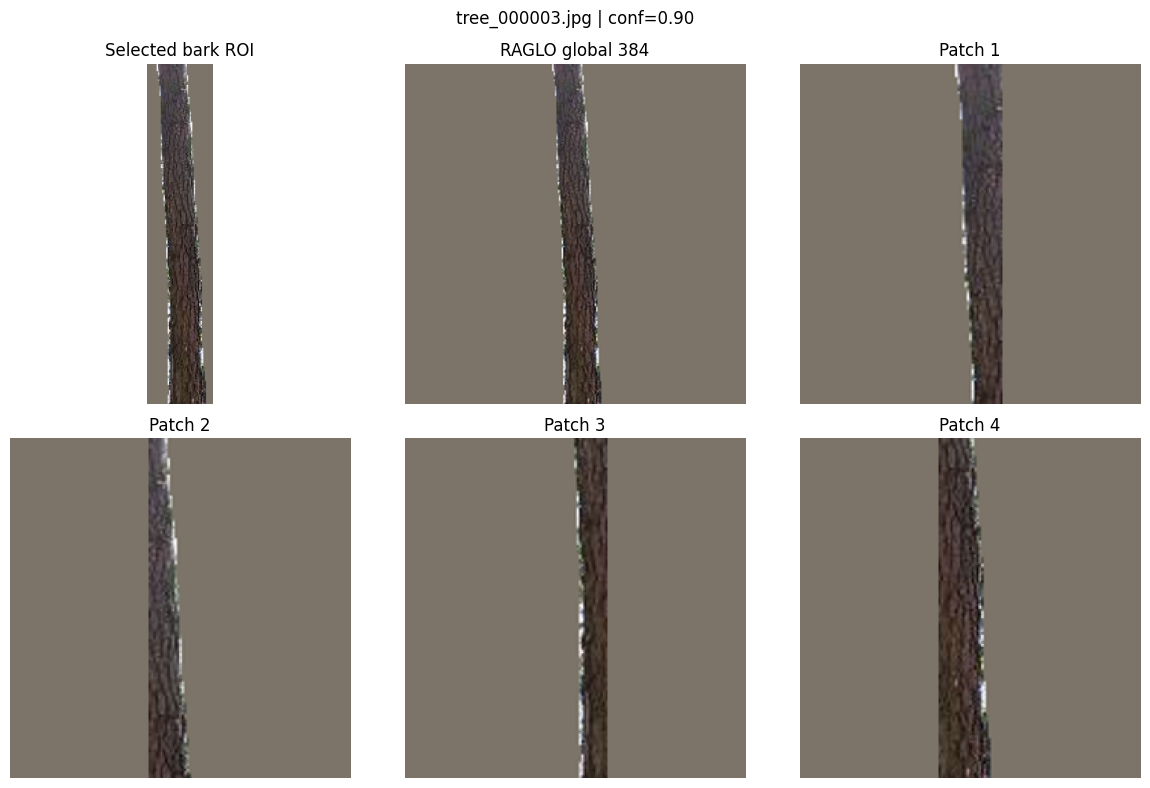

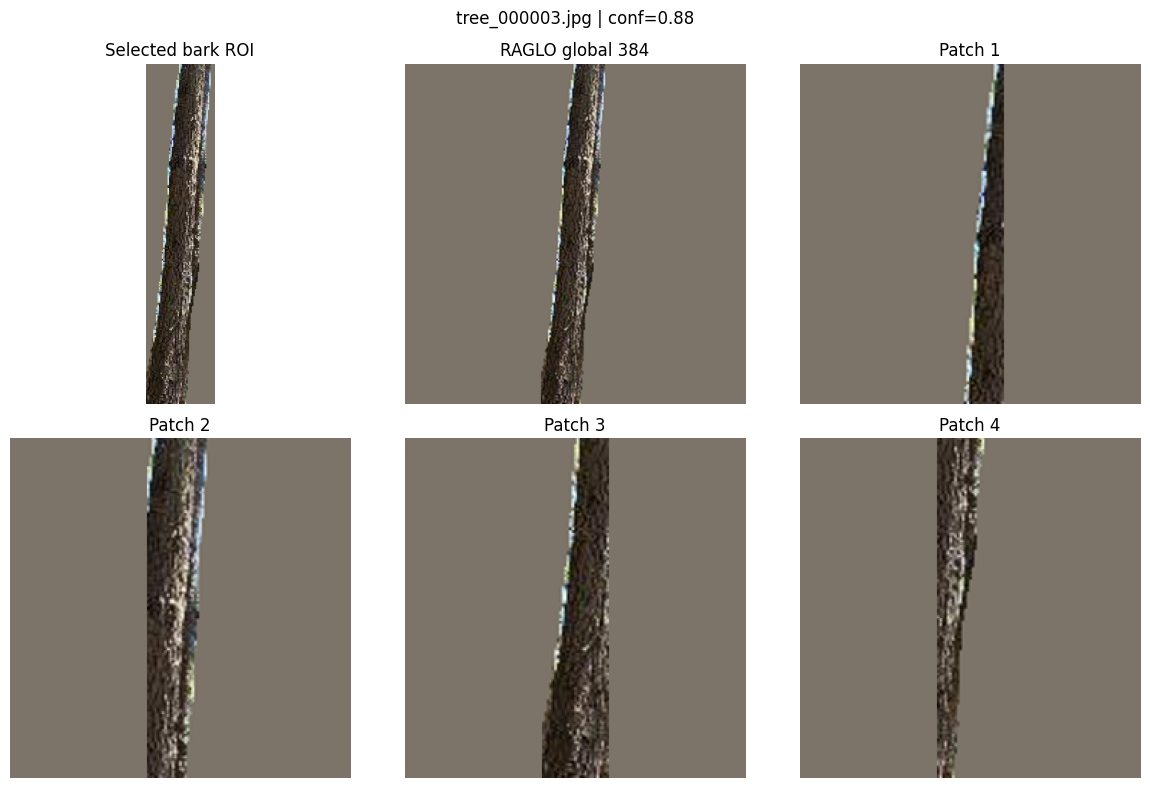

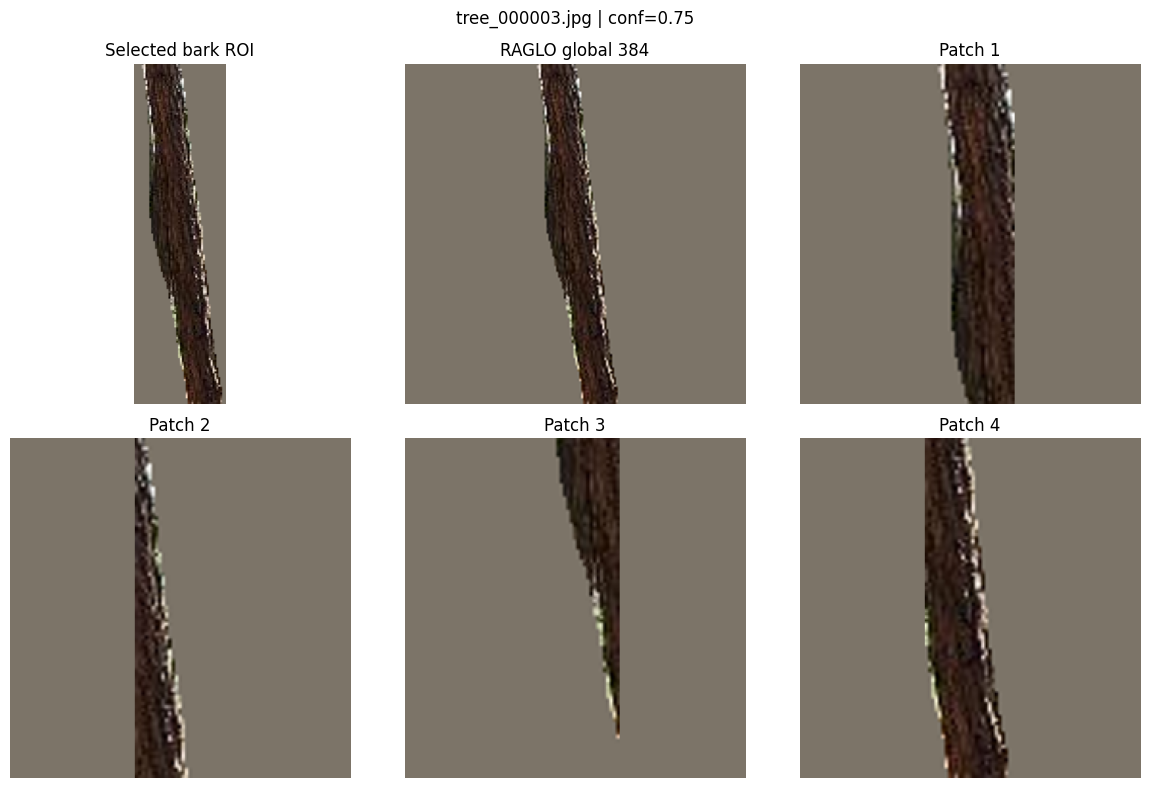

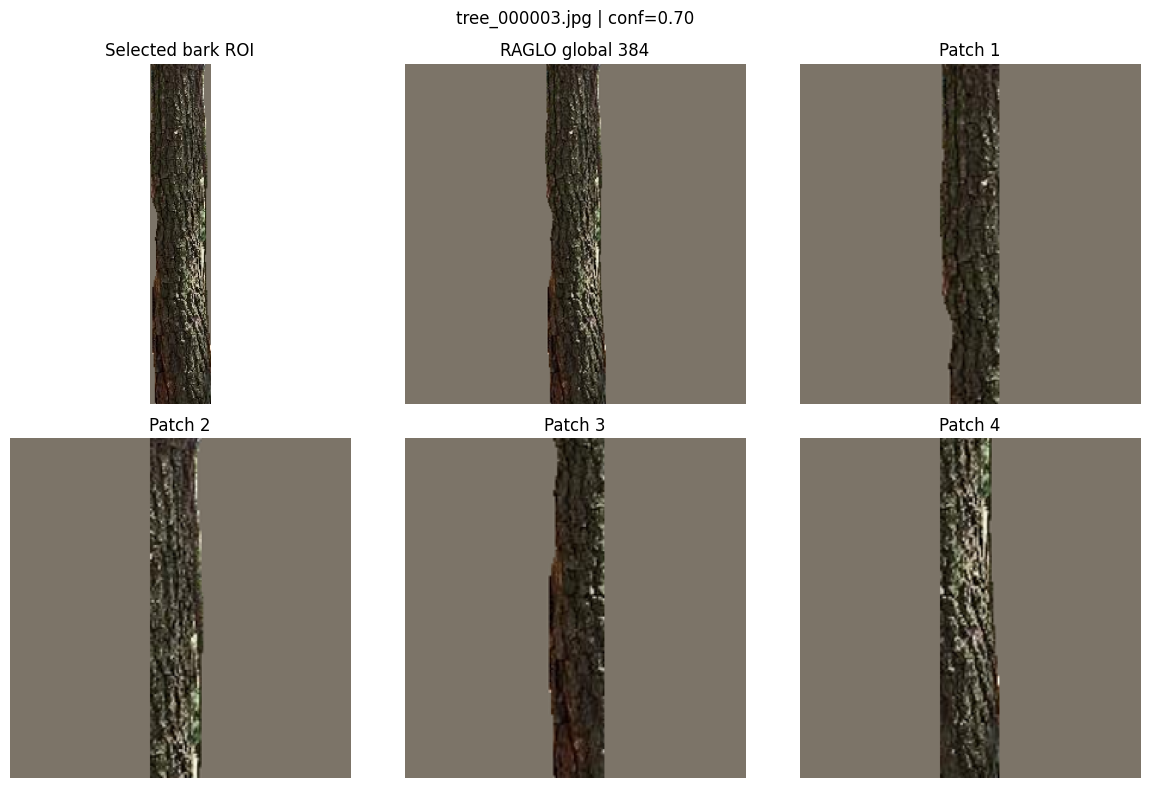

In [25]:
accepted_manifest = raglo_manifest_df[
    raglo_manifest_df["accepted_for_raglo"] == True
].head(4)

for _, row in accepted_manifest.iterrows():
    paths = [
        row["selected_bark_roi"],
        row["global_384"],
        row["patch_1_224"],
        row["patch_2_224"],
        row["patch_3_224"],
        row["patch_4_224"],
    ]
    titles = [
        "Selected bark ROI",
        "RAGLO global 384",
        "Patch 1",
        "Patch 2",
        "Patch 3",
        "Patch 4",
    ]

    figure, axes = plt.subplots(2, 3, figsize=(12, 8))
    for axis, path, title in zip(
        axes.reshape(-1),
        paths,
        titles,
    ):
        with Image.open(path) as image:
            axis.imshow(image.convert("RGB"))
        axis.set_title(title)
        axis.axis("off")

    figure.suptitle(
        f"{row['source_image']} | "
        f"conf={row['detection_confidence']:.2f}"
    )
    plt.tight_layout()
    plt.show()

## 24 — Paper-ready research summary

In [26]:
research_summary = {
    "method_name": "DAACT-YOLO26",

    "method_expansion": (
        "Density- and Assessability-Aware Curriculum Training "
        "for YOLO26 Tree-Trunk Instance Segmentation"
    ),

    "architecture":
        "standard YOLO26s-seg checkpoint",

    "dataset_source":
        source_used,

    "density_claim_supported_on_test":
        bool(DENSITY_CLAIM_SUPPORTED),

    "technical_change": {
        "stage1": (
            "common all-trunk learning with verified "
            "negative/background images retained"
        ),

        "B0": (
            "standard Stage-2 continuation"
        ),

        "A1": (
            "HIGH-density positive-scene emphasis "
            "with all trunk targets retained"
        ),

        "A2": (
            "HIGH-density positive-scene emphasis plus "
            "geometry-defined assessable targets"
        ),

        "scene_groups": {
            "negative": "0 trunks",
            "low": f"1..{DENSITY_LOW_MAX}",
            "medium": (
                f"{DENSITY_LOW_MAX + 1}.."
                f"{DENSITY_MEDIUM_MAX}"
            ),
            "high": (
                f">={DENSITY_MEDIUM_MAX + 1}"
            ),
        },

        "density_repeat": {
            "negative":
                CFG.density_repeat_negative,
            "low":
                CFG.density_repeat_low,
            "medium":
                CFG.density_repeat_medium,
            "high":
                CFG.density_repeat_high,
        },

        "assessable_thresholds_at_1024": {
            "minimum_width":
                CFG.min_assessable_width,
            "minimum_height":
                CFG.min_assessable_height,
            "minimum_polygon_area":
                CFG.min_assessable_area,
        },
    },

    "frozen_dataset": {
        "train_images":
            CFG.expected_train_images,

        "valid_images":
            CFG.expected_valid_images,

        "test_images":
            CFG.expected_test_images,

        "positive_polygon_instances":
            CFG.expected_total_instances,

        "intentional_negative_images":
            EXPECTED_NEGATIVES,

        "scene_counts":
            scene_counts,
    },

    "fairness_controls": {
        "same_common_checkpoint": True,
        "same_stage2_epochs":
            CFG.branch_epochs,
        "same_architecture": True,
        "same_validation_split": True,
        "same_test_split": True,
        "confidence_selected_on_validation_only": True,
        "negative_images_not_density_oversampled": True,
    },

    "results":
        MODEL_RESULTS,

    "raglo_contract": {
        "global_size":
            CFG.raglo_global_size,

        "local_size":
            CFG.raglo_local_size,

        "patch_count":
            CFG.raglo_patch_count,

        "patch_layout":
            "2x2",

        "patch_fraction":
            CFG.raglo_patch_fraction,

        "resize":
            "aspect_fit_then_neutral_pad",

        "mean":
            CFG.imagenet_mean,

        "std":
            CFG.imagenet_std,
    },

    "bark_ready_metrics":
        bark_metrics,

    "claim_rule": (
        "Claim benefit only when A2 is supported by the "
        "predeclared assessable, density, negative-image, "
        "mask-quality and bark-ready metrics relative to B0."
    ),
}

(OUT_DIR / "research_summary.json").write_text(
    json.dumps(
        research_summary,
        indent=2,
        default=str,
    ),
    encoding="utf-8",
)

print(json.dumps(
    {
        "method_name":
            research_summary["method_name"],

        "claim_rule":
            research_summary["claim_rule"],

        "raglo_contract":
            research_summary["raglo_contract"],
    },
    indent=2,
))

{
  "method_name": "DAACT-YOLO26",
  "claim_rule": "Claim benefit only when A2 is supported by the predeclared assessable, density, negative-image, mask-quality and bark-ready metrics relative to B0.",
  "raglo_contract": {
    "global_size": 384,
    "local_size": 224,
    "patch_count": 4,
    "patch_layout": "2x2",
    "patch_fraction": 0.58,
    "resize": "aspect_fit_then_neutral_pad",
    "mean": [
      0.485,
      0.456,
      0.406
    ],
    "std": [
      0.229,
      0.224,
      0.225
    ]
  }
}


## 25 — Copy model artifacts and package deliverables

In [27]:
for variant, model_path in MODEL_PATHS.items():
    destination = OUT_DIR / f"{variant}_best.pt"
    shutil.copy2(model_path, destination)

# Copy common checkpoint for reproducibility.
shutil.copy2(
    COMMON_BEST,
    OUT_DIR / "S0_common_best.pt",
)

# Copy run result CSVs when present.
for run_directory in RUNS_DIR.iterdir():
    if not run_directory.is_dir():
        continue

    result_csv = run_directory / "results.csv"
    args_yaml = run_directory / "args.yaml"

    if result_csv.exists():
        shutil.copy2(
            result_csv,
            OUT_DIR / f"{run_directory.name}_results.csv",
        )
    if args_yaml.exists():
        shutil.copy2(
            args_yaml,
            OUT_DIR / f"{run_directory.name}_args.yaml",
        )

zip_base = WORK / "DAACT_YOLO26_RAGLO_Ready_Deliverables"
zip_path = shutil.make_archive(
    str(zip_base),
    "zip",
    root_dir=OUT_DIR,
)

print("Deliverables ZIP:", zip_path)
print("Proposed model:", OUT_DIR / "A2_DAACT_best.pt")
print(
    "RAGLO-ready manifest:",
    OUT_DIR / "raglo_ready_test_manifest.csv",
)
print(
    "Research comparison:",
    OUT_DIR / "research_ablation_comparison.csv",
)

from IPython.display import FileLink, display
display(FileLink(zip_path))
display(FileLink(str(OUT_DIR / "A2_DAACT_best.pt")))
display(FileLink(str(OUT_DIR / "research_summary.json")))

Deliverables ZIP: /kaggle/working/DAACT_YOLO26_RAGLO_Ready_Deliverables.zip
Proposed model: /kaggle/working/DAACT_YOLO26_Research_Deliverables/A2_DAACT_best.pt
RAGLO-ready manifest: /kaggle/working/DAACT_YOLO26_Research_Deliverables/raglo_ready_test_manifest.csv
Research comparison: /kaggle/working/DAACT_YOLO26_Research_Deliverables/research_ablation_comparison.csv


/kaggle/working/DAACT_YOLO26_RAGLO_Ready_Deliverables.zip

/kaggle/working/DAACT_YOLO26_Research_Deliverables/A2_DAACT_best.pt

/kaggle/working/DAACT_YOLO26_Research_Deliverables/research_summary.json

# What to report in the research evaluation

## 1. Frozen dataset protocol

```text
Train       641 images
Validation  137 images
Test        137 images
Total       915 images

Positive tree-trunk polygons = 4,445

Intentional negative images:
Train 32
Valid 11
Test  12
Total 55
```

Scene groups:

```text
NEGATIVE = 0 trunks
LOW      = 1–5
MEDIUM   = 6–10
HIGH     = 11+
```

Expected audited scene counts:

| Split | Negative | Low | Medium | High |
|---|---:|---:|---:|---:|
| Train | 32 | 423 | 120 | 66 |
| Valid | 11 | 86 | 26 | 14 |
| Test | 12 | 85 | 23 | 17 |

## 2. Technical novelty ablation

Use:

```text
research_ablation_comparison.csv
```

Compare:

| Variant | Meaning |
|---|---|
| B0_STANDARD | ordinary continuation from the common checkpoint |
| A1_DENSITY | B0 + HIGH-density positive-scene emphasis |
| A2_DAACT | A1 + assessability-aligned Stage-2 targets |

Primary operational metrics:

- assessable precision;
- assessable recall;
- assessable F1;
- LOW / MEDIUM / HIGH recall;
- mask IoU;
- Dice;
- negative-image FPR;
- false positives per negative image;
- RAGLO bark-ready coverage.

Secondary metrics:

- box precision / recall / mAP50 / mAP50–95;
- mask precision / recall / mAP50 / mAP50–95.

## 3. Correct contribution language

A defensible statement is:

> We propose a density- and assessability-aware curriculum that first learns
> generic trunk representations and subsequently emphasizes dense plantation
> scenes while aligning segmentation targets with bark-usable trunks. Verified
> background images are retained separately to measure and constrain false
> positives.

Do not claim that YOLO26, oversampling, or geometry thresholds are individually
new.

## 4. RAGLO interface

The A2 output remains:

```text
selected_bark_roi.png
global_384.png
patch_1_224.png
patch_2_224.png
patch_3_224.png
patch_4_224.png
```

RAGLO still applies its normal tensor conversion and ImageNet normalization.

## 5. Final paper

The notebook defaults to one seed for a practical first run. For final evidence,
repeat at least B0 and A2 with several fixed seeds, e.g.:

```text
42
123
3407
```

Report mean ± standard deviation and keep the test set untouched during model
selection.